<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(CTGAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (CTGAN)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **CTGAN** algorithm to do this. CTGAN uses generative adversarial networks (GANs) to create synthesize data with high fidelity.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [1]:
%pip install sdv

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.3
    Uninstalling pandas-3.0.3:
      Successfully uninstalled pandas-3.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
table-evaluator 1.9.0 requires matplotlib==3.9.2, but you have matplotlib 3.10.9 which is incompatible.
table-evaluator 1.9.0 requires numpy==1.26.4, but you have numpy 2.4.4 which is incompatible.
table-evaluator 1.9.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
table-evaluator 1.9.0 requires scikit-learn==1.5.1, but you have scikit-learn 1.8.0 which is incompatible.
table-evaluator 1.9.0 requires scipy==1.12.0, but you have scipy 1.17.1 

In [3]:
!pip install table_evaluator

In [5]:
!pip install dython

# 1. Loading the demo data
For this demo, we'll use a fake dataset that describes some fictional guests staying at a hotel.

In [9]:
from google.colab import files
uploaded = files.upload()


Saving Pretreatment RS.csv to Pretreatment RS (3).csv


In [10]:
import pandas as pd
data = pd.read_csv('Pretreatment RS.csv')

In [11]:
real_data = pd.read_csv('Pretreatment RS.csv')

In [12]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

In [13]:
display(real_data.head())

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,H2O,Original,0.60,0.00,0.61,1.25,1.00,3.17,0.30,0.00,0.88,0.00,0.09,31.67
1,H2O,Treated,0.68,0.00,0.58,1.07,0.94,2.66,0.24,0.00,0.92,0.00,0.00,22.24
2,H2SO4,Original,10.81,2.49,2.55,1.63,3.81,36.70,1.06,0.00,7.65,0.03,0.39,69.84
3,H2SO4,Treated,10.70,0.00,1.89,1.72,4.09,31.10,0.38,0.00,1.31,0.00,0.04,44.40
4,HCl,Original,37.26,4.55,0.66,11.18,5.97,66.37,1.83,0.28,5.46,0.00,0.16,74.64


In [14]:
categorical_features = ['Catalyst', 'samples', 'Xyl','Fur','Glu','Cel','Ara.','Total RS','EtOH','BuOH','Ace.','Prop.','n-But.','COD']

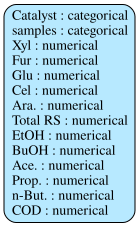

In [15]:
metadata.visualize()

In [16]:
from ctgan import CTGAN
import pandas as pd # Import pandas

# Ensure real_data is loaded if not already in global scope
if 'real_data' not in globals():
    print("Warning: 'real_data' not found. Attempting to load from 'Pretreatment RS.csv'.")
    try:
        real_data = pd.read_csv('Pretreatment RS.csv')
    except FileNotFoundError:
        raise FileNotFoundError("The file 'Pretreatment RS.csv' was not found. Please ensure it's uploaded and named correctly.")
    print("'real_data' reloaded successfully.")

# Ensure categorical_features is defined if not already in global scope
if 'categorical_features' not in globals():
    print("Warning: 'categorical_features' not found. Re-defining.")
    categorical_features = ['Catalyst', 'samples', 'Xyl','Fur','Glu','Cel','Ara.','Total RS','EtOH','BuOH','Ace.','Prop.','n-But.','COD']
    print("'categorical_features' re-defined successfully.")

ctgan = CTGAN(verbose=True)
ctgan.fit(real_data, categorical_features, epochs=200)

Gen. (+01.30) | Discrim. (-00.81): 100%|██████████| 200/200 [00:22<00:00,  8.93it/s]


### Training a Gaussian Copula Synthesizer (GMM)

In [18]:
from sdv.single_table import GaussianCopulaSynthesizer

# Initialize the GaussianCopulaSynthesizer
gmm_synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the real data
gmm_synthesizer.fit(real_data)
print("GaussianCopulaSynthesizer trained successfully.")

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


GaussianCopulaSynthesizer trained successfully.


### Generating Synthetic Data with GMM

In [19]:
# Generate synthetic data using the GMM synthesizer
synthetic_data_from_gmm = gmm_synthesizer.sample(len(real_data) * 10)

print(f"Generated {len(synthetic_data_from_gmm)} synthetic rows using GMM.")
display(synthetic_data_from_gmm.head())

Generated 80 synthetic rows using GMM.


,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Original,29.38,3.95,2.55,7.26,5.36,63.29,1.34,0.0,7.59,0.0,0.37,65.09
1,HCl,Treated,12.33,0.01,1.26,4.56,2.05,27.93,0.49,0.0,4.85,0.0,0.32,34.83
2,HNO3,Original,25.99,0.01,0.59,7.90,6.73,62.12,0.94,0.0,1.13,0.0,0.07,77.07
3,H2SO4,Original,6.44,0.17,2.55,2.32,2.89,10.53,1.02,0.0,7.62,0.0,0.37,45.47
4,H2O,Original,7.76,0.10,0.36,3.39,5.74,5.99,0.27,0.0,0.70,0.0,0.04,73.91


### Evaluating Quality of GMM Synthetic Data

In [20]:
from sdv.evaluation.single_table import evaluate_quality

# Evaluate the quality of the synthetic data generated by GMM
quality_report_gmm = evaluate_quality(
    real_data,
    synthetic_data_from_gmm,
    metadata
)

print("Overall Quality Score (GMM):", quality_report_gmm.get_score())
display(quality_report_gmm.get_details(property_name='Column Shapes'))
display(quality_report_gmm.get_details(property_name='Column Pair Trends'))

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 545.01it/s]|
Column Shapes Score: 75.89%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 121.92it/s]|
Column Pair Trends Score: 66.38%

Overall Score (Average): 71.13%

Overall Quality Score (GMM): 0.7113417055816843


,Column,Metric,Score
0,Catalyst,TVComplement,0.9500
1,samples,TVComplement,0.9125
2,Xyl,KSComplement,0.6875
3,Fur,KSComplement,0.6625
4,Glu,KSComplement,0.7250
5,Cel,KSComplement,0.5750
6,Ara.,KSComplement,0.7250
7,Total RS,KSComplement,0.7875
8,EtOH,KSComplement,0.7875
9,BuOH,KSComplement,0.9875


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xyl,ContingencySimilarity,0.150000,NaN,NaN,1.000000,True
2,Catalyst,Fur,ContingencySimilarity,0.537500,NaN,NaN,0.632456,True
3,Catalyst,Glu,ContingencySimilarity,0.237500,NaN,NaN,0.781736,True
4,Catalyst,Cel,ContingencySimilarity,0.237500,NaN,NaN,0.707107,True
...,...,...,...,...,...,...,...,...
86,Ace.,n-But.,CorrelationSimilarity,0.952496,0.834040,0.739033,NaN,True
87,Ace.,COD,CorrelationSimilarity,0.743864,0.595639,0.083366,NaN,True
88,Prop.,n-But.,CorrelationSimilarity,0.709859,0.905719,0.325436,NaN,True
89,Prop.,COD,CorrelationSimilarity,NaN,0.236673,NaN,NaN,False


In [21]:
from sdmetrics.single_table.detection import LogisticDetection

# Re-sample synthetic data after re-training the CTGAN model for evaluation
synthetic_data_from_ctgan = ctgan.sample(len(real_data) * 10)

# Compute the LogisticDetection metric
# A higher score indicates lower privacy (easier to distinguish real from synthetic),
# which can be a sign of overfitting.
logistic_detection_score = LogisticDetection.compute(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    metadata=metadata.to_dict() # Convert metadata object to dictionary
)

print(f"Logistic Detection Score: {logistic_detection_score:.4f}")

# Interpretation:
# A score closer to 0 indicates better privacy (harder to distinguish real from synthetic),
# suggesting less overfitting.
# A score closer to 1 indicates worse privacy (easier to distinguish real from synthetic),
# suggesting higher risk of overfitting/memorization.

Logistic Detection Score: 1.0000



--- SHAP Analysis for Real Data ---
SHAP Summary Plot for Real Data:


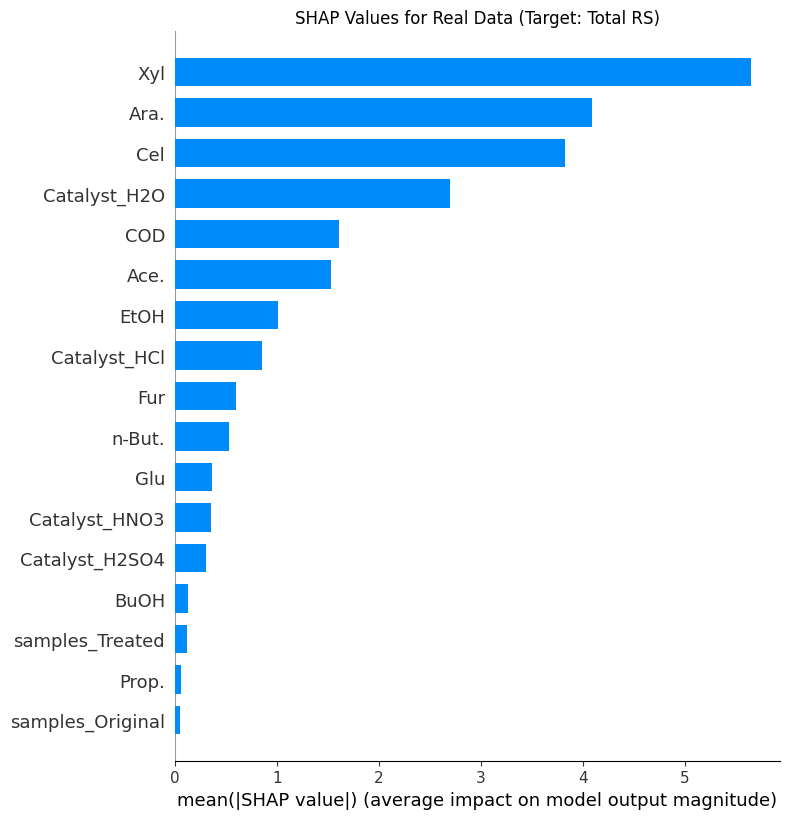


--- SHAP Analysis for CTGAN Synthetic Data ---
SHAP Summary Plot for CTGAN Synthetic Data:


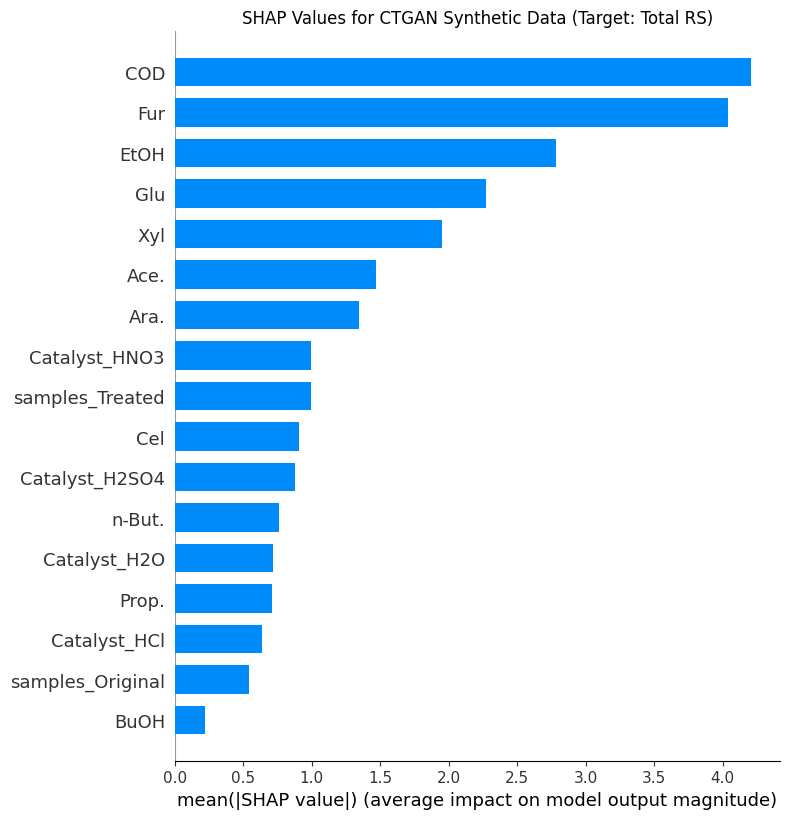


--- SHAP Analysis for GMM Synthetic Data ---
SHAP Summary Plot for GMM Synthetic Data:


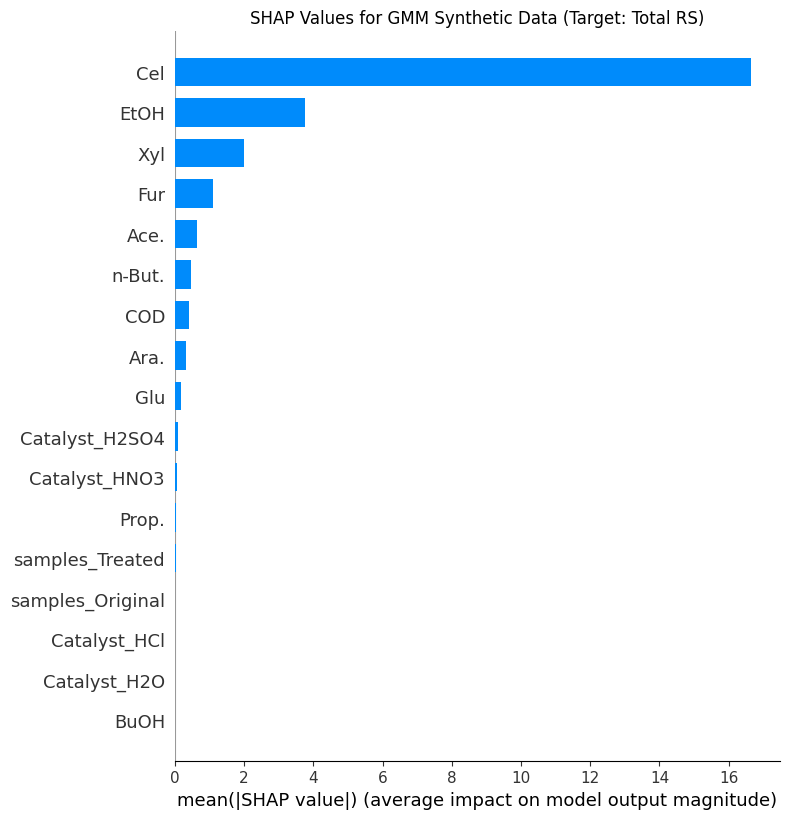

In [22]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Define target and features (using variables from kernel state)
target_column = 'Total RS'
categorical_cols_for_model = ['Catalyst', 'samples']

# Prepare dataframes for modeling (one-hot encode categorical features)
def preprocess_data_for_shap(df, categorical_features_list, target):
    # Drop target column for features
    X = df.drop(columns=[target], errors='ignore')
    y = df[target]

    # Apply one-hot encoding to specified categorical columns
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_encoded = encoder.fit_transform(X[categorical_features_list])
    encoded_feature_names = encoder.get_feature_names_out(categorical_features_list)
    X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names, index=X.index)

    # Drop original categorical columns and concatenate encoded ones
    X_numeric = X.drop(columns=categorical_features_list)
    X_processed = pd.concat([X_numeric, X_encoded_df], axis=1)

    return X_processed, y, encoder

def make_shap_plots(shap_values, data_processed, model_name):
    print(f"SHAP Summary Plot for {model_name} Data:")
    shap.summary_plot(shap_values, data_processed, plot_type="bar", show=False)
    plt.title(f'SHAP Values for {model_name} Data (Target: {target_column})')
    plt.tight_layout()
    plt.show()

# --- SHAP Analysis for Real Data ---
print("\n--- SHAP Analysis for Real Data ---")

X_real_processed, y_real, real_encoder = preprocess_data_for_shap(real_data, categorical_cols_for_model, target_column)

# Train a RandomForestRegressor on the real data
real_model = RandomForestRegressor(n_estimators=100, random_state=42)
real_model.fit(X_real_processed, y_real)

# Explain the model's predictions using SHAP
real_explainer = shap.TreeExplainer(real_model)
real_shap_values = real_explainer.shap_values(X_real_processed)

# Plot the SHAP summary for Real Data
make_shap_plots(real_shap_values, X_real_processed, 'Real')

# --- SHAP Analysis for CTGAN Synthetic Data ---
print("\n--- SHAP Analysis for CTGAN Synthetic Data ---")

X_ctgan_processed, y_ctgan, ctgan_encoder = preprocess_data_for_shap(synthetic_data_from_ctgan, categorical_cols_for_model, target_column)

# Train a RandomForestRegressor on the CTGAN synthetic data
ctgan_model = RandomForestRegressor(n_estimators=100, random_state=42)
ctgan_model.fit(X_ctgan_processed, y_ctgan)

# Explain the model's predictions using SHAP
ctgan_explainer = shap.TreeExplainer(ctgan_model)
ctgan_shap_values = ctgan_explainer.shap_values(X_ctgan_processed)

# Plot the SHAP summary for CTGAN
make_shap_plots(ctgan_shap_values, X_ctgan_processed, 'CTGAN Synthetic')

# --- SHAP Analysis for GMM Synthetic Data ---
print("\n--- SHAP Analysis for GMM Synthetic Data ---")

X_gmm_processed, y_gmm, gmm_encoder = preprocess_data_for_shap(synthetic_data_from_gmm, categorical_cols_for_model, target_column)

# Train a RandomForestRegressor on the GMM synthetic data
gmm_model = RandomForestRegressor(n_estimators=100, random_state=42)
gmm_model.fit(X_gmm_processed, y_gmm)

# Explain the model's predictions using SHAP
gmm_explainer = shap.TreeExplainer(gmm_model)
gmm_shap_values = gmm_explainer.shap_values(X_gmm_processed)

# Plot the SHAP summary for GMM
make_shap_plots(gmm_shap_values, X_gmm_processed, 'GMM Synthetic')


--- Generating SHAP Dependence Plots for Real Data ---

SHAP Dependence Plot for 'Xyl' in Real Data (Target: Total RS):


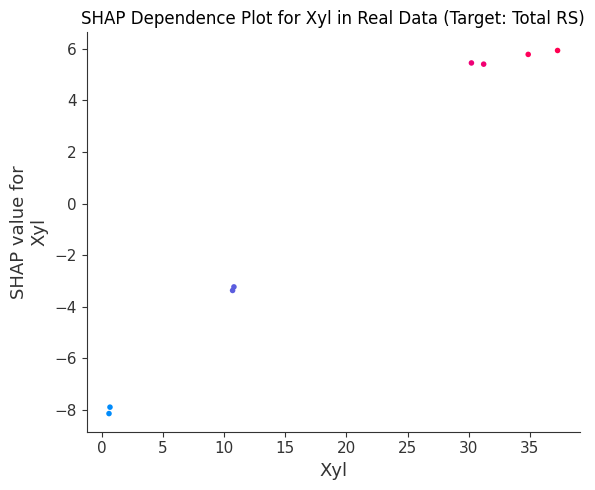


SHAP Dependence Plot for 'Glu' in Real Data (Target: Total RS):


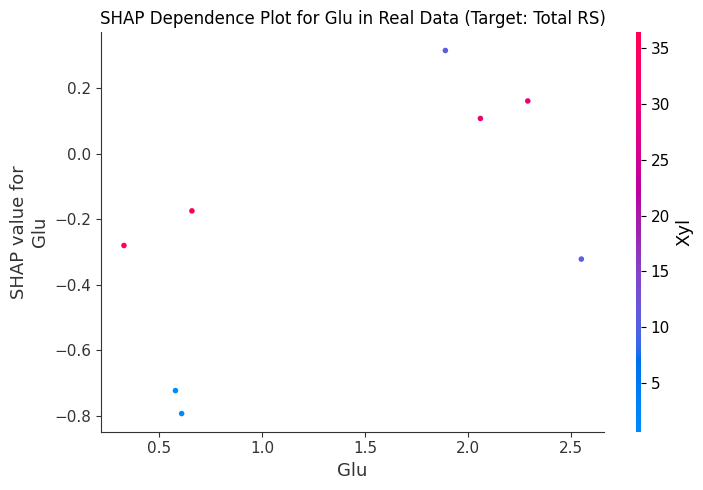


SHAP Dependence Plot for 'n-But.' in Real Data (Target: Total RS):


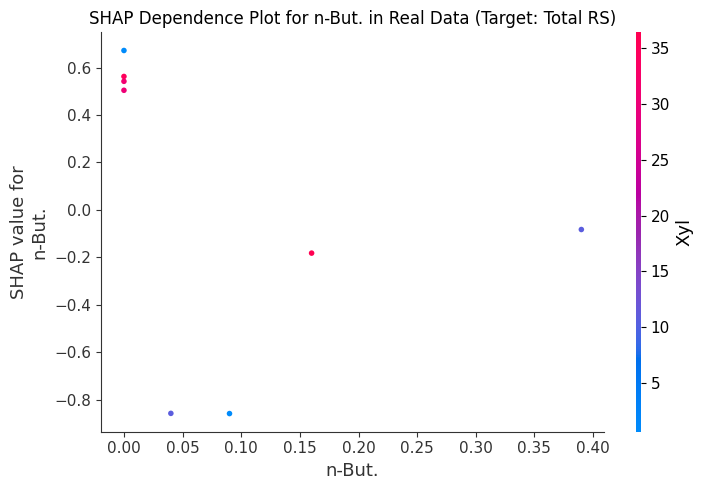


--- Generating SHAP Dependence Plots for CTGAN Synthetic Data ---

SHAP Dependence Plot for 'Xyl' in CTGAN Synthetic Data (Target: Total RS):


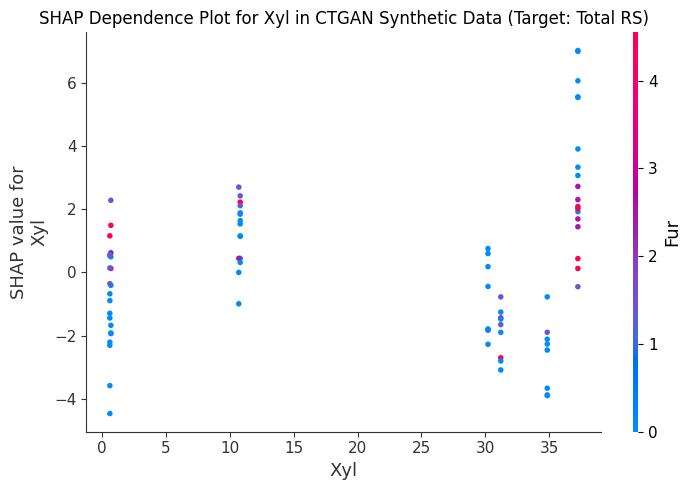


SHAP Dependence Plot for 'Glu' in CTGAN Synthetic Data (Target: Total RS):


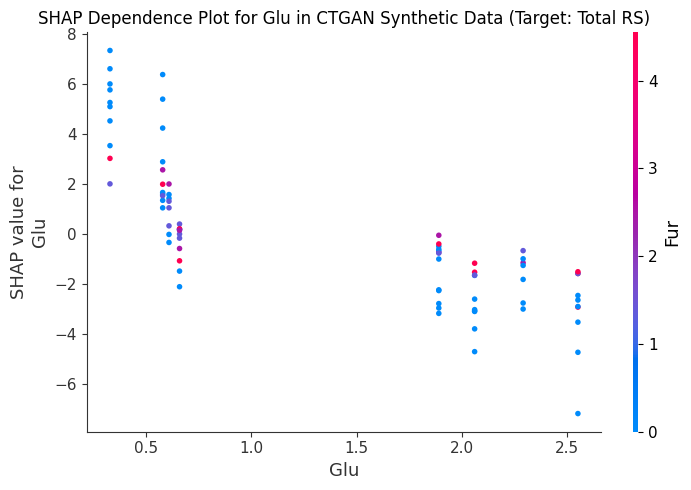


SHAP Dependence Plot for 'n-But.' in CTGAN Synthetic Data (Target: Total RS):


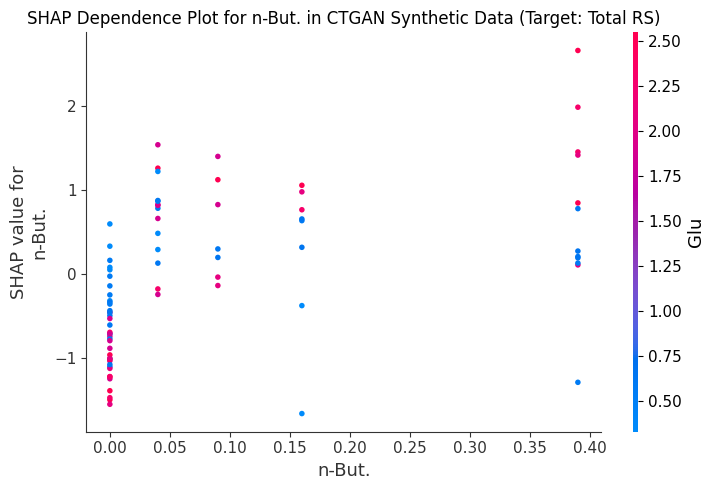


--- Generating SHAP Dependence Plots for GMM Synthetic Data ---

SHAP Dependence Plot for 'Xyl' in GMM Synthetic Data (Target: Total RS):


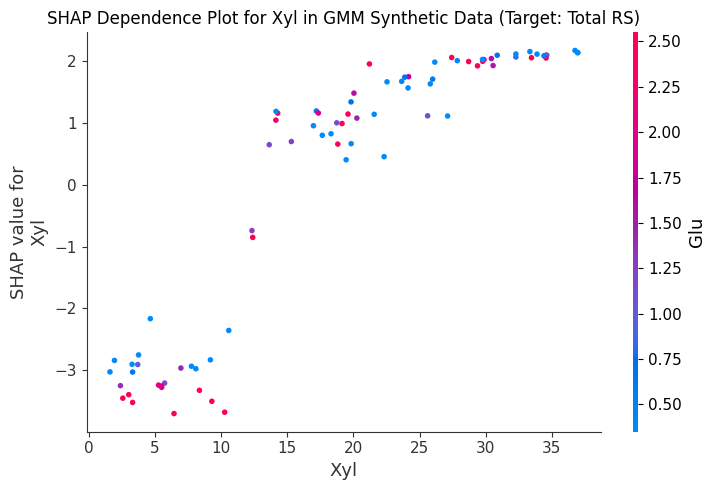


SHAP Dependence Plot for 'Glu' in GMM Synthetic Data (Target: Total RS):


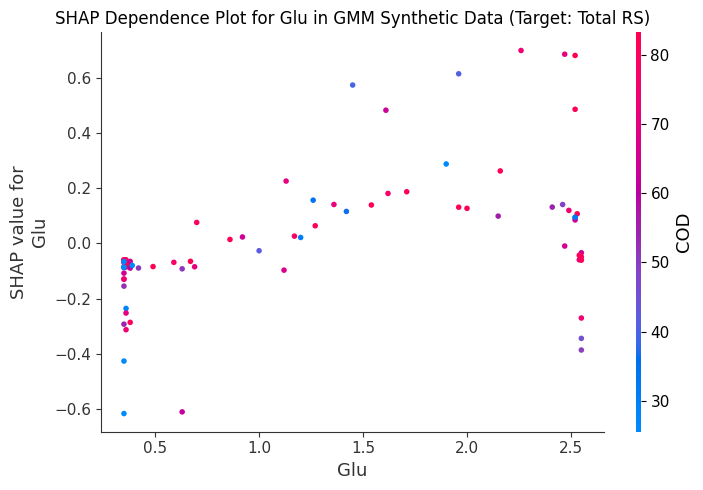


SHAP Dependence Plot for 'n-But.' in GMM Synthetic Data (Target: Total RS):


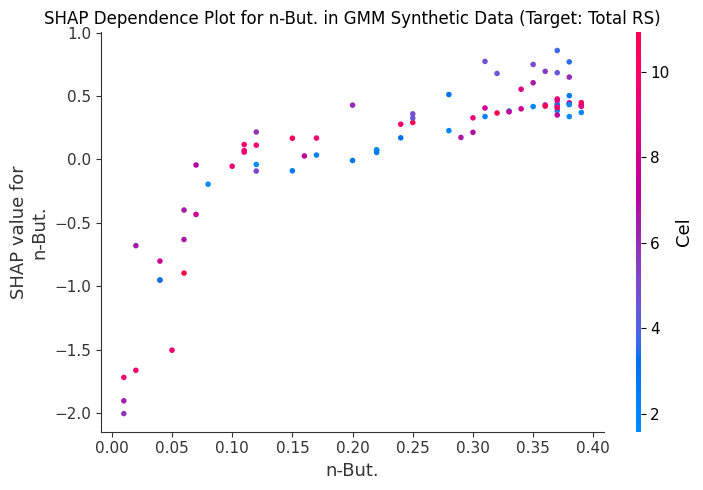

In [27]:
import shap
import matplotlib.pyplot as plt

def plot_feature_dependence(shap_values, processed_data, feature_to_plot, model_name, target_column):
    print(f"\nSHAP Dependence Plot for '{feature_to_plot}' in {model_name} Data (Target: {target_column}):")
    # Ensure processed_data columns are consistent with shap_values columns for correct plotting
    # This is implicitly handled if X_processed was used to generate shap_values
    shap.dependence_plot(
        ind=feature_to_plot,
        shap_values=shap_values,
        features=processed_data,
        display_features=processed_data,
        show=False # Prevent immediate display to allow custom title/layout
    )
    plt.title(f'SHAP Dependence Plot for {feature_to_plot} in {model_name} Data (Target: {target_column})')
    plt.tight_layout()
    plt.show()

# List of numerical features to generate dependence plots for
numerical_features_for_dependence = ['Xyl', 'Glu', 'n-But.']

# Generate dependence plots for Real Data
print("\n--- Generating SHAP Dependence Plots for Real Data ---")
for feature in numerical_features_for_dependence:
    plot_feature_dependence(real_shap_values, X_real_processed, feature, 'Real', target_column)

# Generate dependence plots for CTGAN Synthetic Data
print("\n--- Generating SHAP Dependence Plots for CTGAN Synthetic Data ---")
for feature in numerical_features_for_dependence:
    plot_feature_dependence(ctgan_shap_values, X_ctgan_processed, feature, 'CTGAN Synthetic', target_column)

# Generate dependence plots for GMM Synthetic Data
print("\n--- Generating SHAP Dependence Plots for GMM Synthetic Data ---")
for feature in numerical_features_for_dependence:
    plot_feature_dependence(gmm_shap_values, X_gmm_processed, feature, 'GMM Synthetic', target_column)



--- Clustering Analysis of Feature Contributions ---
Clustering analysis performed on feature contributions with 3 clusters.

Distribution of samples across clusters:


Cluster
1    94
2    57
0    17
Name: count, dtype: int64

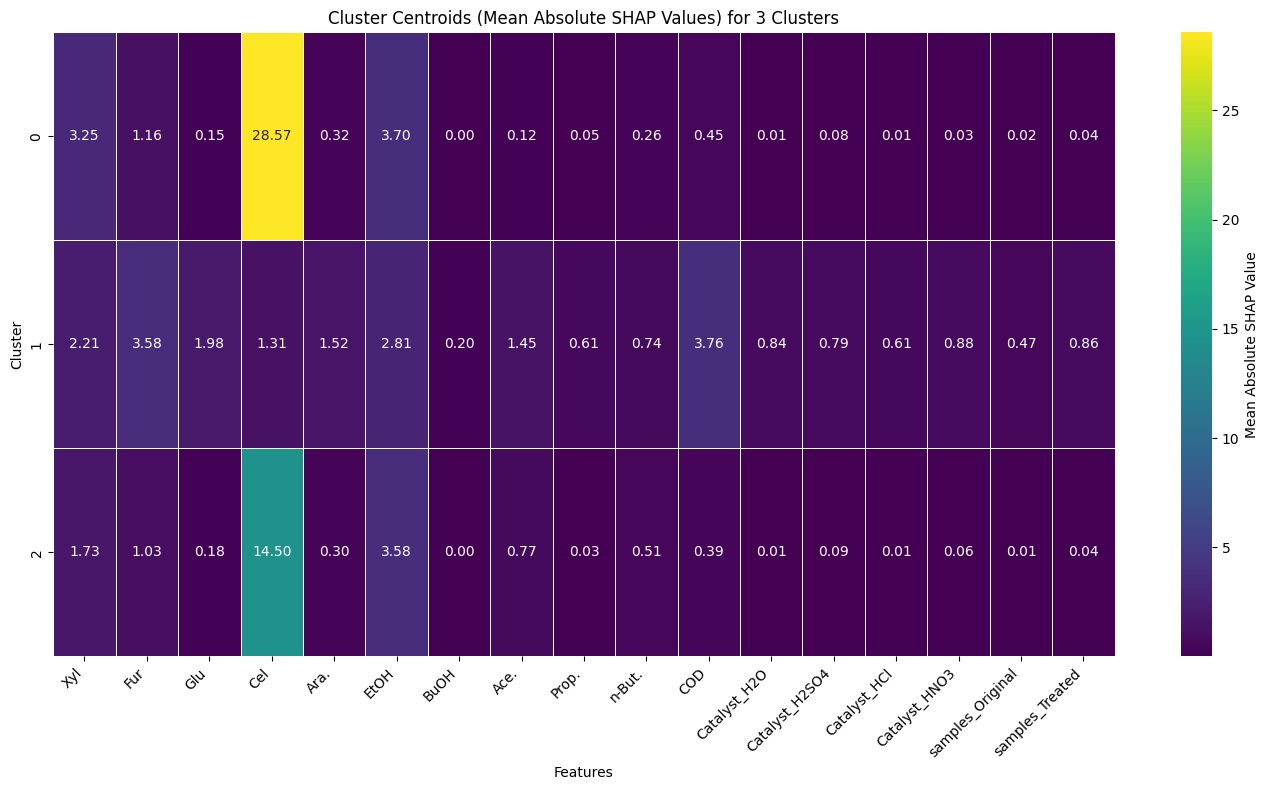


Cluster composition by data source (normalized):


Source,CTGAN,GMM,Real
Cluster,,,
0,0.000000,1.00000,0.000000
1,0.851064,0.06383,0.085106
2,0.000000,1.00000,0.000000


In [26]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Clustering Analysis of Feature Contributions ---")

# Ensure shap_values are 2D arrays if they are lists (e.g., for multi-output models)
def get_2d_shap_values(shap_values_input):
    if isinstance(shap_values_input, list):
        return shap_values_input[0]
    return shap_values_input

real_shap_values_array = get_2d_shap_values(real_shap_values)
ctgan_shap_values_array = get_2d_shap_values(ctgan_shap_values)
gmm_shap_values_array = get_2d_shap_values(gmm_shap_values)

# Get feature names from one of the processed dataframes (they should be the same)
feature_names = X_real_processed.columns

# Create DataFrames of absolute SHAP values
abs_shap_real = pd.DataFrame(np.abs(real_shap_values_array), columns=feature_names)
abs_shap_ctgan = pd.DataFrame(np.abs(ctgan_shap_values_array), columns=feature_names)
abs_shap_gmm = pd.DataFrame(np.abs(gmm_shap_values_array), columns=feature_names)

# Add a 'Source' column to differentiate for later analysis
abs_shap_real['Source'] = 'Real'
abs_shap_ctgan['Source'] = 'CTGAN'
abs_shap_gmm['Source'] = 'GMM'

# Combine all absolute SHAP values for clustering
combined_abs_shap = pd.concat([abs_shap_real, abs_shap_ctgan, abs_shap_gmm], ignore_index=True)

# Select only feature columns for clustering
features_for_clustering = combined_abs_shap.drop(columns=['Source'])

# Perform K-Means clustering
# Choosing 3 clusters as a starting point, corresponding to the three data sources,
# but the optimal number could be determined using methods like the Elbow Method.
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
combined_abs_shap['Cluster'] = kmeans.fit_predict(features_for_clustering)

print(f"Clustering analysis performed on feature contributions with {n_clusters} clusters.")
print("\nDistribution of samples across clusters:")
display(combined_abs_shap['Cluster'].value_counts())

# Visualize the cluster centroids (mean absolute SHAP values for each feature within each cluster)
cluster_centroids = combined_abs_shap.groupby('Cluster')[feature_names].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_centroids, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Mean Absolute SHAP Value'})
plt.title(f'Cluster Centroids (Mean Absolute SHAP Values) for {n_clusters} Clusters')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optional: Analyze cluster composition by data source to see if clusters are dominated by specific data types
print("\nCluster composition by data source (normalized):")
cluster_source_composition = combined_abs_shap.groupby('Cluster')['Source'].value_counts(normalize=True).unstack(fill_value=0)
display(cluster_source_composition)


In [25]:
import numpy as np
import pandas as pd

def get_feature_importance_order(shap_values, feature_names):
    # For tree explainers, shap_values can be a list if it's a multi-output model
    # or just a single array. We'll assume a single array for simplicity or take the first if it's a list.
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Calculate mean absolute SHAP value for each feature
    mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)

    # Create a DataFrame for sorting
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap_values
    })

    # Sort by importance in descending order
    feature_importance = feature_importance.sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
    return feature_importance

print("\n--- Feature Importance Order (Real Data) ---")
real_importance = get_feature_importance_order(real_shap_values, X_real_processed.columns)
display(real_importance)

print("\n--- Feature Importance Order (CTGAN Synthetic Data) ---")
ctgan_importance = get_feature_importance_order(ctgan_shap_values, X_ctgan_processed.columns)
display(ctgan_importance)

print("\n--- Feature Importance Order (GMM Synthetic Data) ---")
gmm_importance = get_feature_importance_order(gmm_shap_values, X_gmm_processed.columns)
display(gmm_importance)

# --- Comparison ---
print("\n--- Comparison of Top 5 Feature Importance ---")
comparison_df = pd.DataFrame({
    'Real Data': real_importance['Feature'].head(5),
    'CTGAN Synthetic': ctgan_importance['Feature'].head(5),
    'GMM Synthetic': gmm_importance['Feature'].head(5)
})
display(comparison_df)



--- Feature Importance Order (Real Data) ---


,Feature,Mean_Abs_SHAP
0,Xyl,5.647784
1,Ara.,4.084559
2,Cel,3.825065
3,Catalyst_H2O,2.697677
4,COD,1.608064
5,Ace.,1.534540
6,EtOH,1.013358
7,Catalyst_HCl,0.857342
8,Fur,0.595667
9,n-But.,0.532193



--- Feature Importance Order (CTGAN Synthetic Data) ---


,Feature,Mean_Abs_SHAP
0,COD,4.207962
1,Fur,4.039375
2,EtOH,2.781178
3,Glu,2.273570
4,Xyl,1.952565
5,Ace.,1.465457
6,Ara.,1.346447
7,Catalyst_HNO3,0.992494
8,samples_Treated,0.990902
9,Cel,0.906540



--- Feature Importance Order (GMM Synthetic Data) ---


,Feature,Mean_Abs_SHAP
0,Cel,16.648702
1,EtOH,3.752605
2,Xyl,1.995661
3,Fur,1.090064
4,Ace.,0.652761
5,n-But.,0.470726
6,COD,0.417152
7,Ara.,0.310860
8,Glu,0.176376
9,Catalyst_H2SO4,0.099443



--- Comparison of Top 5 Feature Importance ---


,Real Data,CTGAN Synthetic,GMM Synthetic
0,Xyl,COD,Cel
1,Ara.,Fur,EtOH
2,Cel,EtOH,Xyl
3,Catalyst_H2O,Glu,Fur
4,COD,Xyl,Ace.



--- Generating SHAP Dependence Plots for Real Data ---

SHAP Dependence Plot for 'Xyl' in Real Data (Target: Total RS):


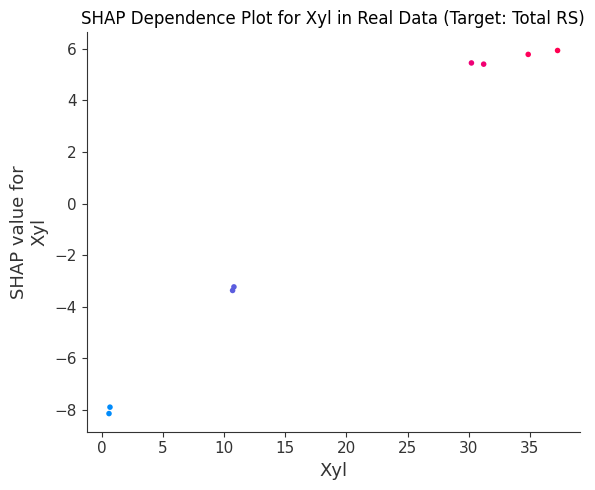


SHAP Dependence Plot for 'Glu' in Real Data (Target: Total RS):


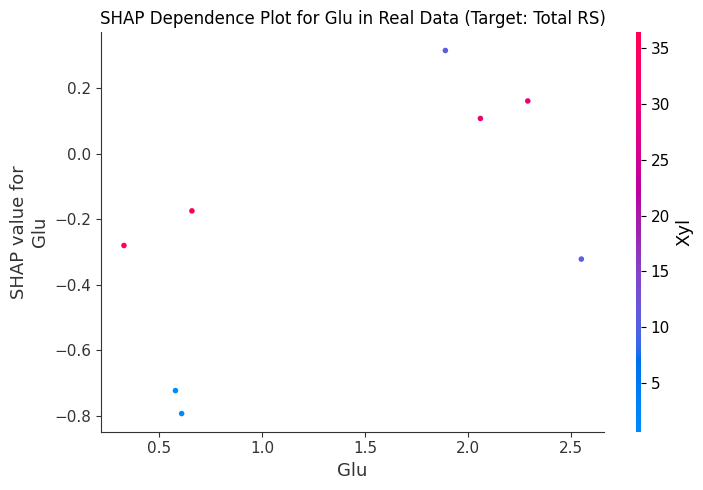


SHAP Dependence Plot for 'n-But.' in Real Data (Target: Total RS):


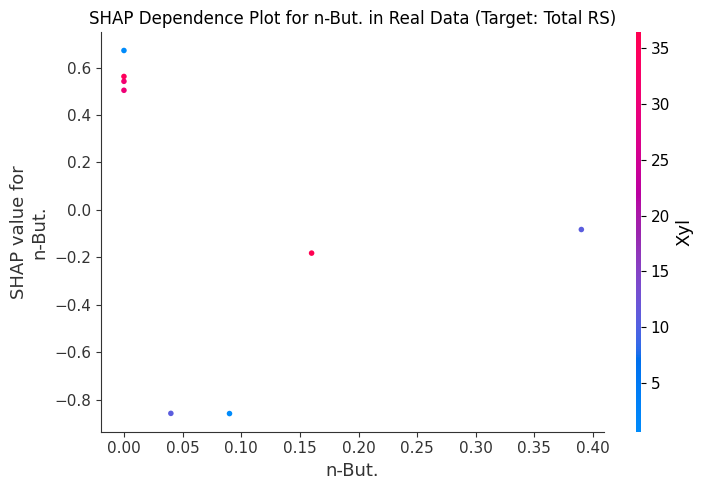


--- Generating SHAP Dependence Plots for CTGAN Synthetic Data ---

SHAP Dependence Plot for 'Xyl' in CTGAN Synthetic Data (Target: Total RS):


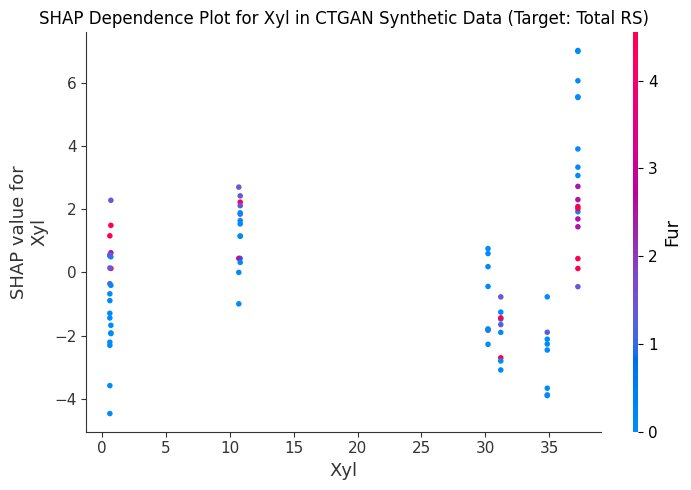


SHAP Dependence Plot for 'Glu' in CTGAN Synthetic Data (Target: Total RS):


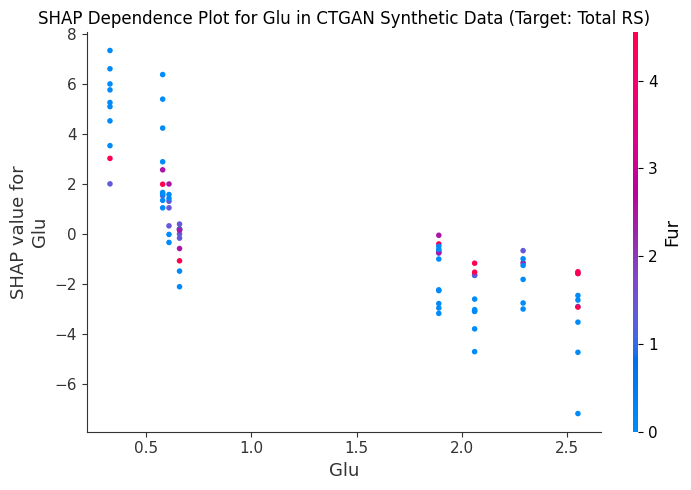


SHAP Dependence Plot for 'n-But.' in CTGAN Synthetic Data (Target: Total RS):


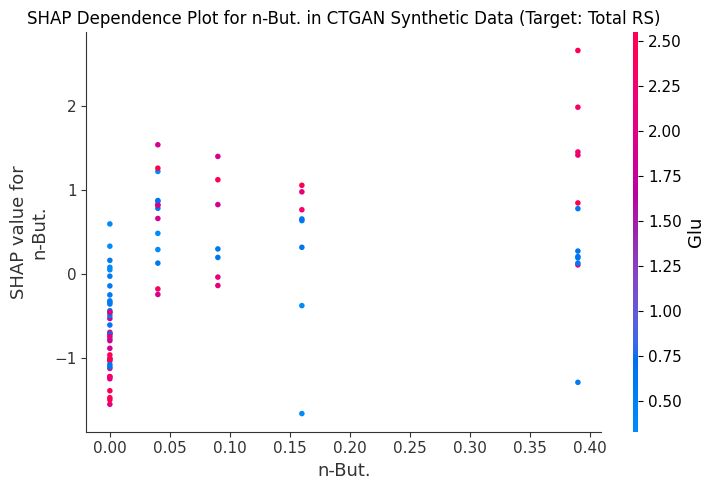


--- Generating SHAP Dependence Plots for GMM Synthetic Data ---

SHAP Dependence Plot for 'Xyl' in GMM Synthetic Data (Target: Total RS):


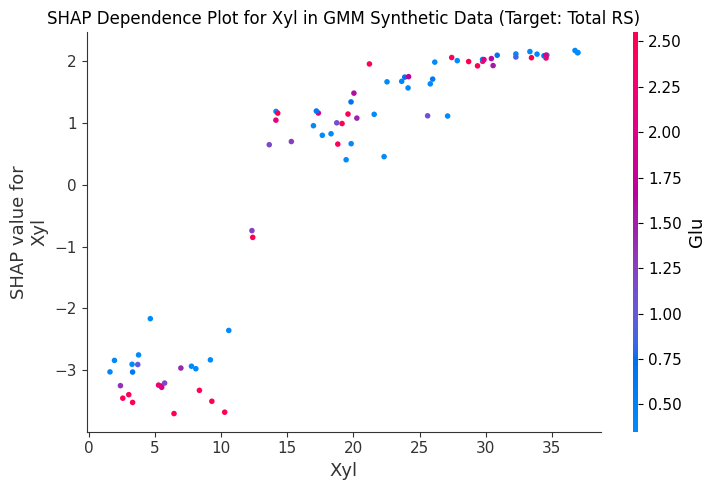


SHAP Dependence Plot for 'Glu' in GMM Synthetic Data (Target: Total RS):


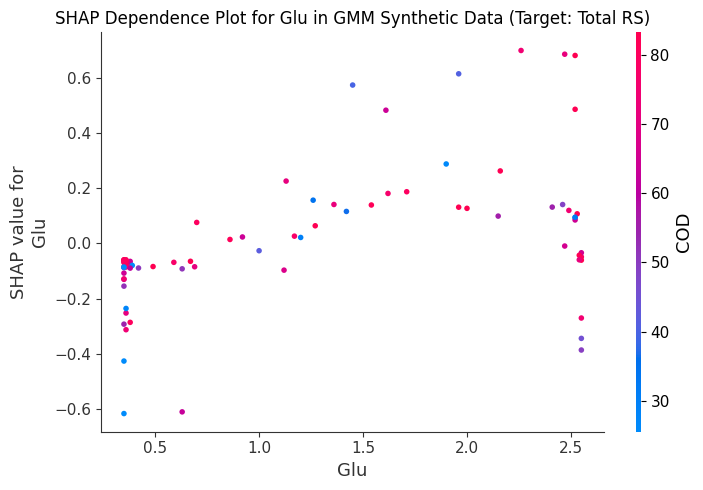


SHAP Dependence Plot for 'n-But.' in GMM Synthetic Data (Target: Total RS):


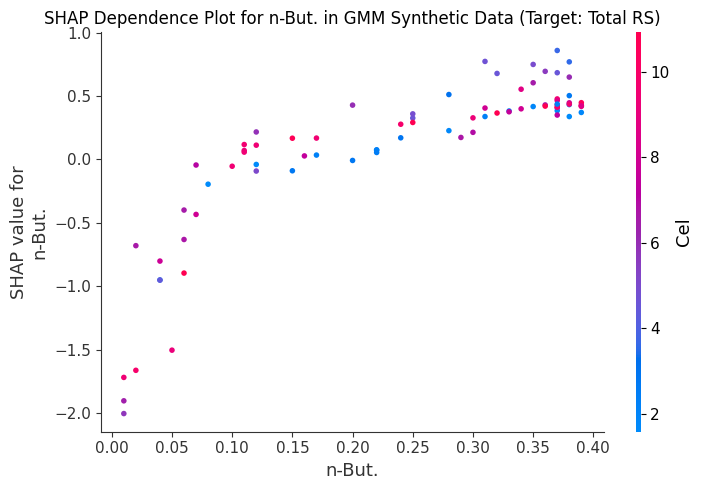

In [23]:
import shap
import matplotlib.pyplot as plt

def plot_feature_dependence(shap_values, processed_data, feature_to_plot, model_name, target_column):
    print(f"\nSHAP Dependence Plot for '{feature_to_plot}' in {model_name} Data (Target: {target_column}):")
    shap.dependence_plot(
        ind=feature_to_plot,
        shap_values=shap_values,
        features=processed_data,
        display_features=processed_data,
        show=False # Prevent immediate display to allow custom title/layout
    )
    plt.title(f'SHAP Dependence Plot for {feature_to_plot} in {model_name} Data (Target: {target_column})')
    plt.tight_layout()
    plt.show()

# List of numerical features to generate dependence plots for
numerical_features_for_dependence = ['Xyl', 'Glu', 'n-But.']

# Generate dependence plots for Real Data
print("\n--- Generating SHAP Dependence Plots for Real Data ---")
for feature in numerical_features_for_dependence:
    plot_feature_dependence(real_shap_values, X_real_processed, feature, 'Real', target_column)

# Generate dependence plots for CTGAN Synthetic Data
print("\n--- Generating SHAP Dependence Plots for CTGAN Synthetic Data ---")
for feature in numerical_features_for_dependence:
    plot_feature_dependence(ctgan_shap_values, X_ctgan_processed, feature, 'CTGAN Synthetic', target_column)

# Generate dependence plots for GMM Synthetic Data
print("\n--- Generating SHAP Dependence Plots for GMM Synthetic Data ---")
for feature in numerical_features_for_dependence:
    plot_feature_dependence(gmm_shap_values, X_gmm_processed, feature, 'GMM Synthetic', target_column)


--- SHAP Summary Plot (Dot) for Real Data ---


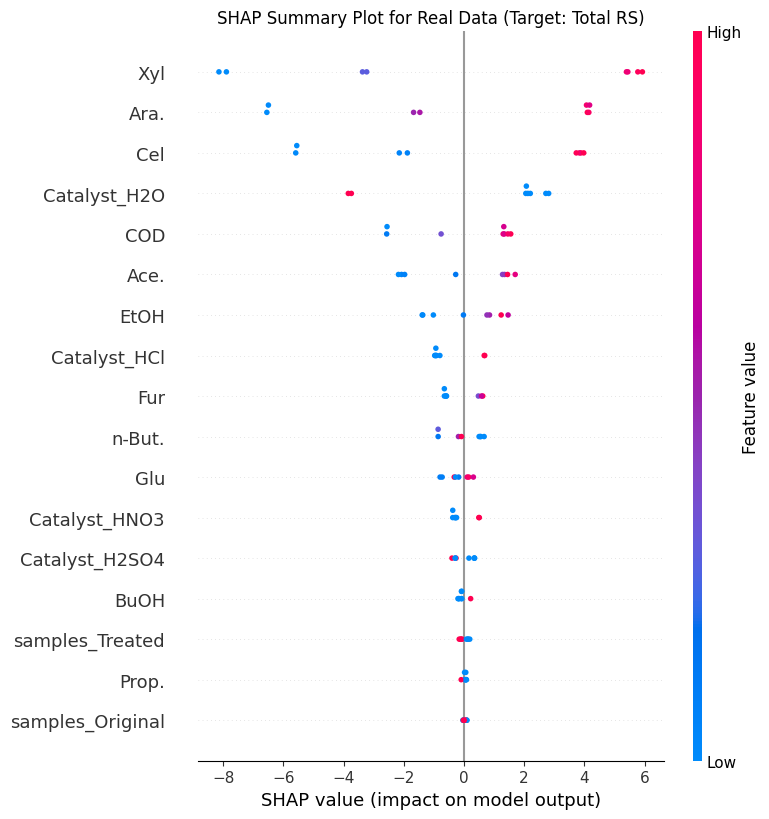


--- SHAP Summary Plot (Dot) for CTGAN Synthetic Data ---


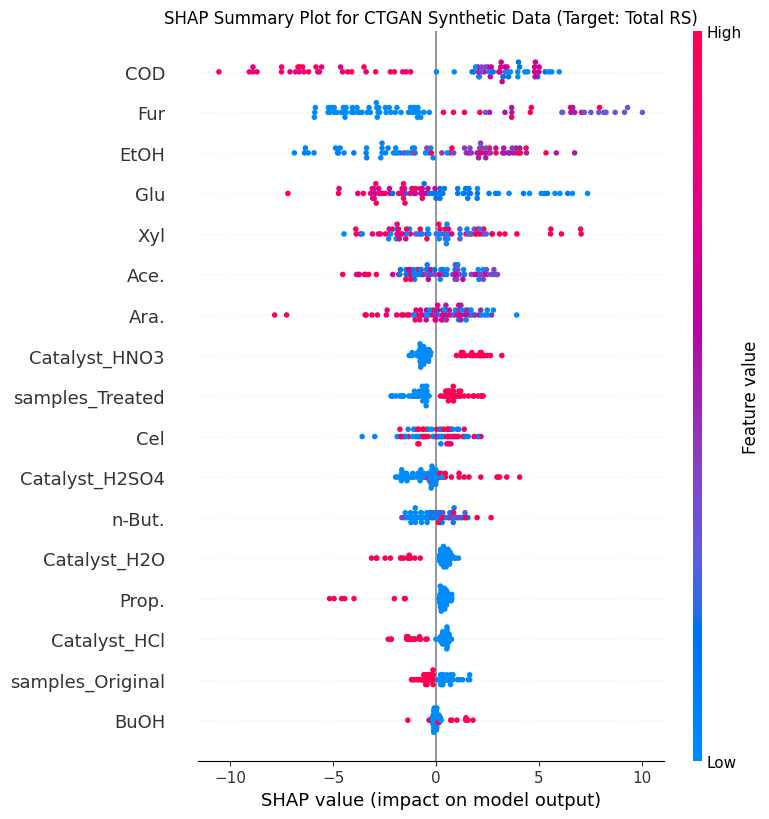


--- SHAP Summary Plot (Dot) for GMM Synthetic Data ---


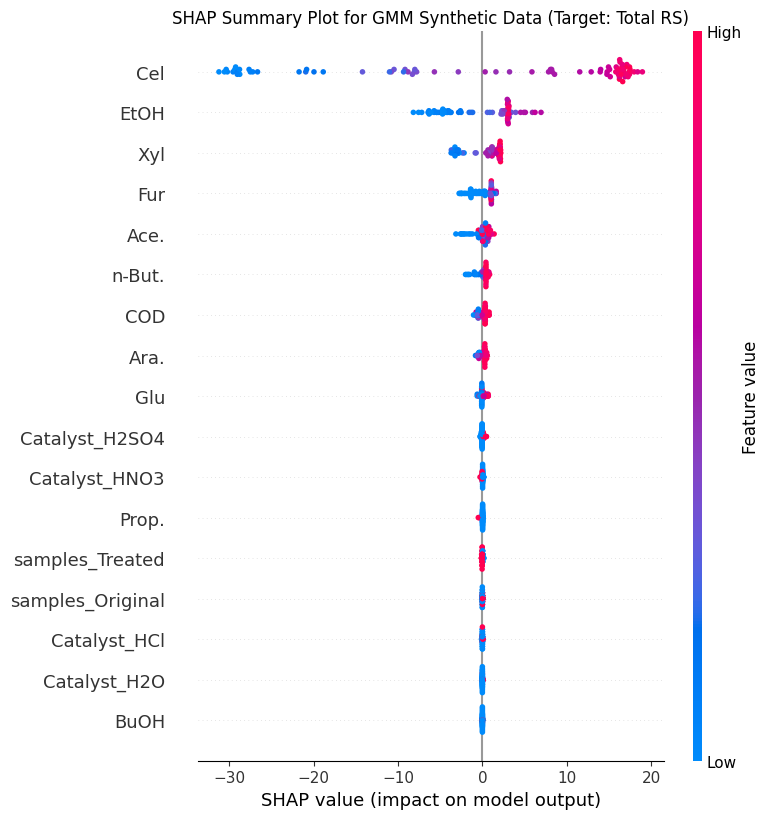

In [24]:
import matplotlib.pyplot as plt
import shap

# --- SHAP Summary Plot (Dot) for Real Data ---
print("\n--- SHAP Summary Plot (Dot) for Real Data ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(real_shap_values, X_real_processed, plot_type="dot", show=False)
plt.title(f'SHAP Summary Plot for Real Data (Target: {target_column})')
plt.tight_layout()
plt.show()

# --- SHAP Summary Plot (Dot) for CTGAN Synthetic Data ---
print("\n--- SHAP Summary Plot (Dot) for CTGAN Synthetic Data ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(ctgan_shap_values, X_ctgan_processed, plot_type="dot", show=False)
plt.title(f'SHAP Summary Plot for CTGAN Synthetic Data (Target: {target_column})')
plt.tight_layout()
plt.show()

# --- SHAP Summary Plot (Dot) for GMM Synthetic Data ---
print("\n--- SHAP Summary Plot (Dot) for GMM Synthetic Data ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(gmm_shap_values, X_gmm_processed, plot_type="dot", show=False)
plt.title(f'SHAP Summary Plot for GMM Synthetic Data (Target: {target_column})')
plt.tight_layout()
plt.show()

In [20]:
from sdv.evaluation.single_table import evaluate_quality

# Ensure metadata is in dictionary format (this block is now commented out
# as evaluate_quality expects the metadata object directly)
# if 'metadata' in globals() and not isinstance(metadata, dict):
#     try:
#         metadata_dict = metadata.to_dict()
#     except AttributeError:
#         metadata_dict = metadata # Already a dict or other compatible format
# else:
#     metadata_dict = metadata

quality_report_ctgan = evaluate_quality(
    real_data,
    synthetic_data_from_ctgan,
    metadata # Pass metadata object directly; evaluate_quality handles conversion
)

print("Overall Quality Score (CTGAN):", quality_report_ctgan.get_score())
display(quality_report_ctgan.get_details(property_name='Column Shapes'))
display(quality_report_ctgan.get_details(property_name='Column Pair Trends'))

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 559.32it/s]|
Column Shapes Score: 91.7%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 118.02it/s]|
Column Pair Trends Score: 56.22%

Overall Score (Average): 73.96%

Overall Quality Score (CTGAN): 0.7395924783105965


,Column,Metric,Score
0,Catalyst,TVComplement,0.8875
1,samples,TVComplement,0.7750
2,Xyl,KSComplement,0.9500
3,Fur,KSComplement,0.9250
4,Glu,KSComplement,0.9125
5,Cel,KSComplement,0.9625
6,Ara.,KSComplement,0.9000
7,Total RS,KSComplement,0.9000
8,EtOH,KSComplement,0.9250
9,BuOH,KSComplement,0.9750


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xyl,ContingencySimilarity,0.250000,NaN,NaN,1.000000,True
2,Catalyst,Fur,ContingencySimilarity,0.537500,NaN,NaN,0.632456,True
3,Catalyst,Glu,ContingencySimilarity,0.462500,NaN,NaN,0.781736,True
4,Catalyst,Cel,ContingencySimilarity,0.337500,NaN,NaN,0.707107,True
...,...,...,...,...,...,...,...,...
86,Ace.,n-But.,CorrelationSimilarity,0.549345,0.834040,-0.067271,NaN,True
87,Ace.,COD,CorrelationSimilarity,0.672966,0.595639,-0.058430,NaN,True
88,Prop.,n-But.,CorrelationSimilarity,0.565760,0.905719,0.037238,NaN,True
89,Prop.,COD,CorrelationSimilarity,NaN,0.236673,NaN,NaN,False


The privacy report score helps quantify how well the synthetic data protects the privacy of the real data. A higher score typically indicates better privacy preservation (less overfitting/memorization). For very small datasets, achieving a high score while maintaining utility can be challenging.

In [21]:
from sdv.evaluation.single_table import get_column_plot

fig_glu = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_name='Glu',
    metadata=metadata
)

fig_glu.show()

The demo also includes **metadata**, a description of the dataset. It includes the primary keys as well as the data types for each column (called "sdtypes").

# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

<font color="maroon"><i><b>This step takes a few minutes.</b> For larger datasets, this phase may take longer. A drawback of a GAN-based model like CTGAN is performance.</i></font>

When this code finishes running, the synthesizer is ready to use.

## 2.2 Generating Synthetic Data
Use the `sample` function and pass in any number of rows to synthesize.

In [25]:
samples = ctgan.sample(80)

In [26]:
samples

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Treated,30.22,0.00,2.29,11.02,3.81,2.66,1.06,0.0,1.31,0.0,0.09,83.90
1,HNO3,Original,37.26,2.49,2.06,11.18,6.23,61.60,0.84,0.0,0.27,0.0,0.00,64.50
2,H2O,Original,0.60,2.49,2.29,10.82,1.00,3.17,0.92,0.0,0.92,0.0,0.00,44.40
3,HNO3,Original,0.60,1.37,2.55,11.02,3.81,66.37,0.24,0.0,1.31,0.0,0.00,31.67
4,H2SO4,Original,30.22,0.00,2.06,11.02,6.23,36.70,0.24,0.0,3.25,0.0,0.00,74.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,H2O,Treated,30.22,4.55,0.58,1.63,4.09,31.10,0.24,0.0,3.25,0.0,0.09,44.40
76,HCl,Treated,30.22,2.49,2.29,11.18,3.81,61.60,0.38,0.0,0.88,0.0,0.00,83.90
77,HNO3,Original,0.60,1.37,0.61,1.63,0.94,3.17,0.92,0.0,7.65,0.0,0.39,31.67
78,HCl,Treated,31.22,0.00,2.06,10.82,6.23,61.60,0.92,0.0,1.31,0.0,0.00,44.40


In [27]:
quality_report_ctgan.get_score()

np.float64(0.7395924783105965)

The synthesizer is generating synthetic guests in the **same format as the original data**.

## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [29]:
from table_evaluator import TableEvaluator
print(real_data.shape, samples.shape)

# Create a new categorical features list excluding 'Total RS' for table_evaluator
features_for_table_evaluator = [col for col in categorical_features if col != 'Total RS']

# The following lines are commented out due to a 'ValueError: underlying array is read-only'
# that occurs within the table_evaluator library, likely due to dependency version conflicts.
# table_evaluator = TableEvaluator(real_data.copy(), samples.copy(), features_for_table_evaluator)
# table_evaluator.evaluate(target_col='Total RS', target_type='regr')
# table_evaluator.visual_evaluation()

print("TableEvaluator functionality has been commented out due to an internal library error.")

(8, 14) (80, 14)
TableEvaluator functionality has been commented out due to an internal library error.


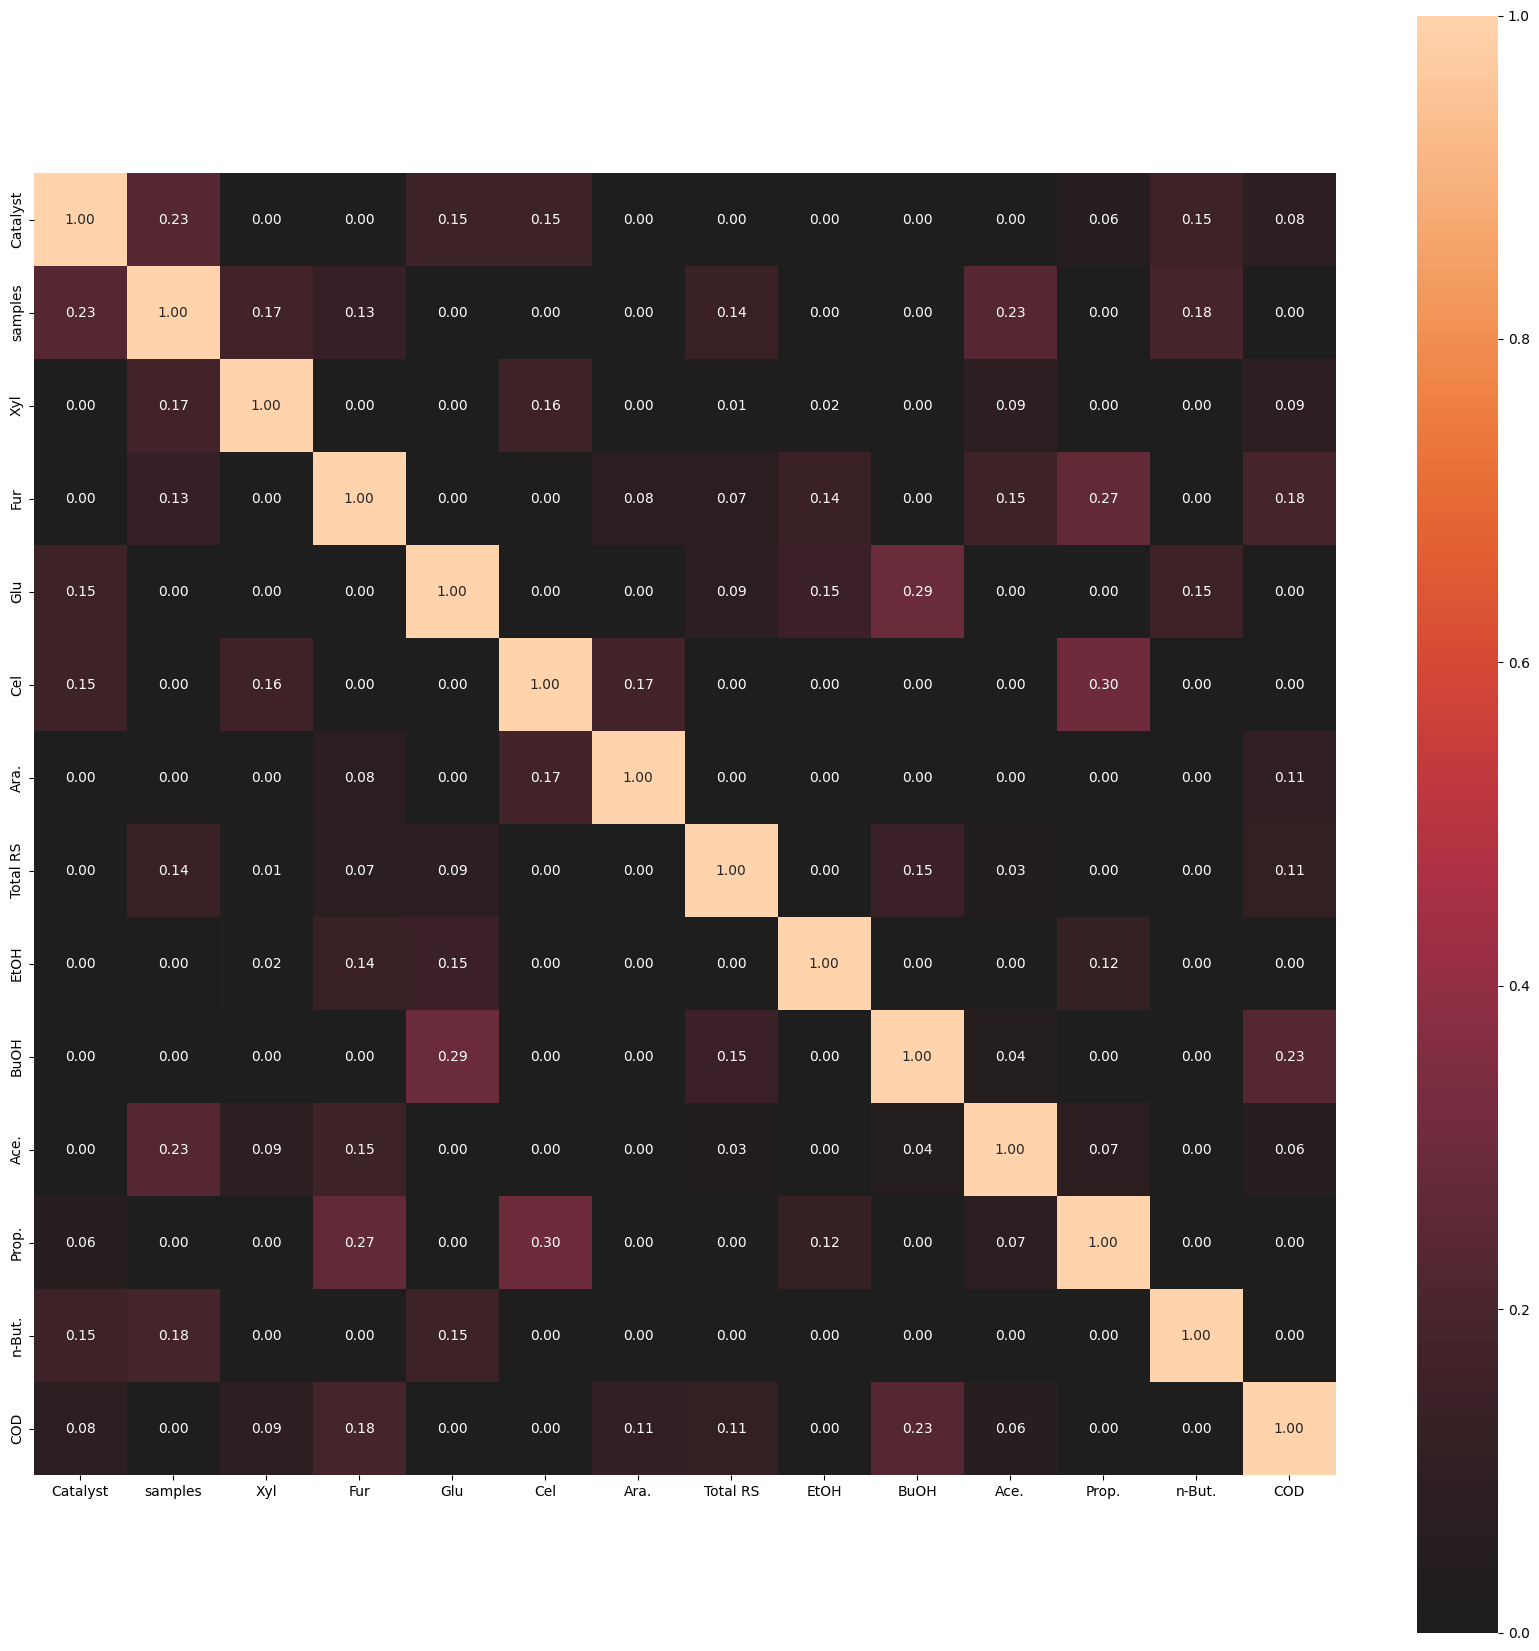

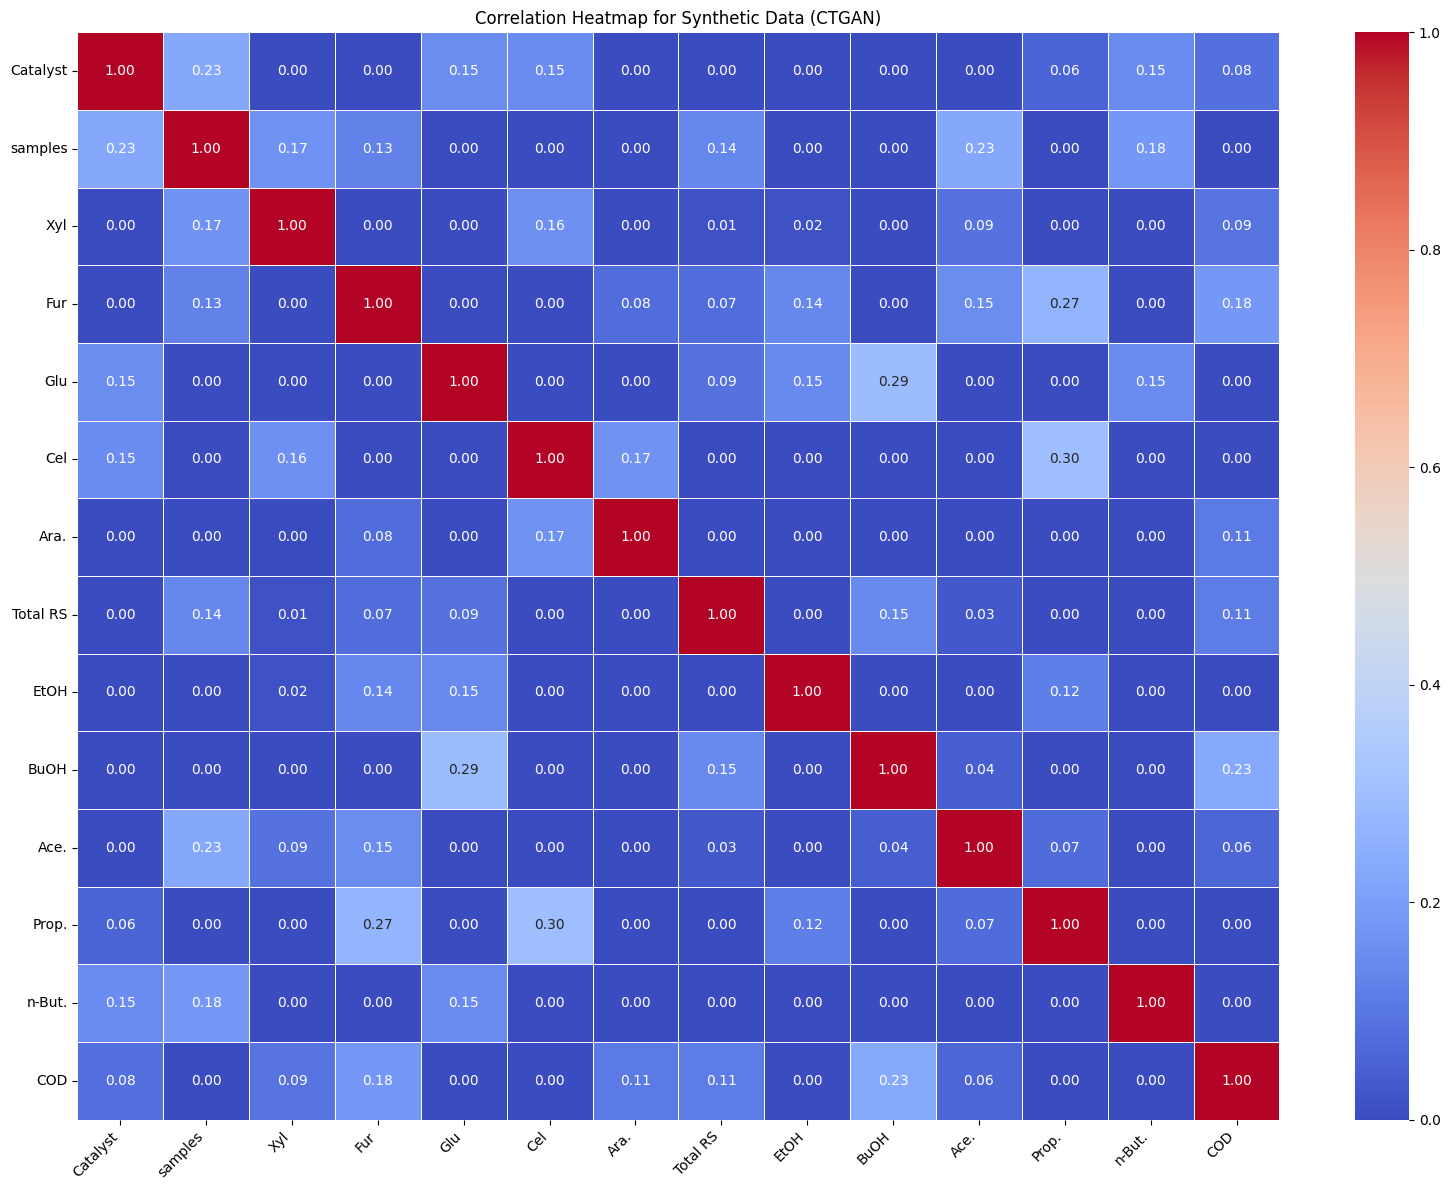

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

# Calculate associations for mixed data types using dython
# The associations function can handle both numerical and categorical columns
correlation_matrix = associations(synthetic_data_from_ctgan, nominal_columns=categorical_features, plot=False)['corr']

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Synthetic Data (CTGAN)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Violin Plots for All Features (Real vs. CTGAN vs. GMM)

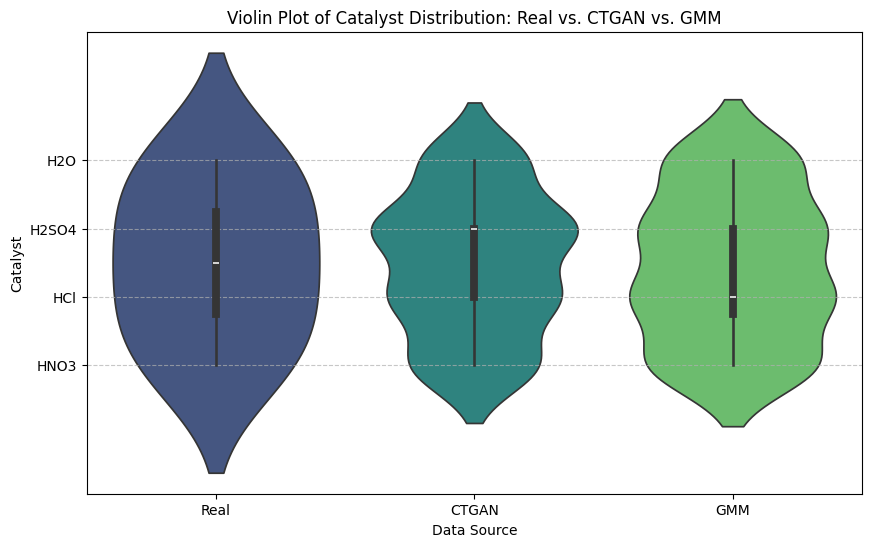

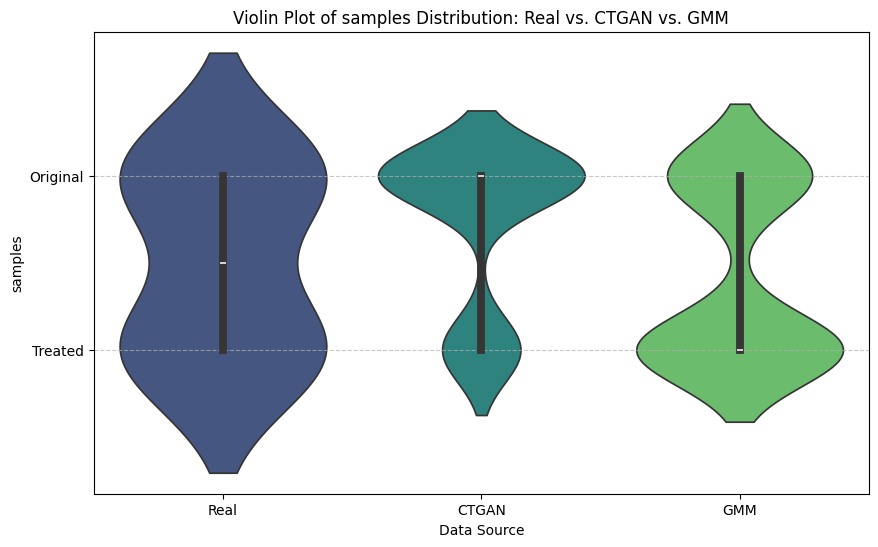

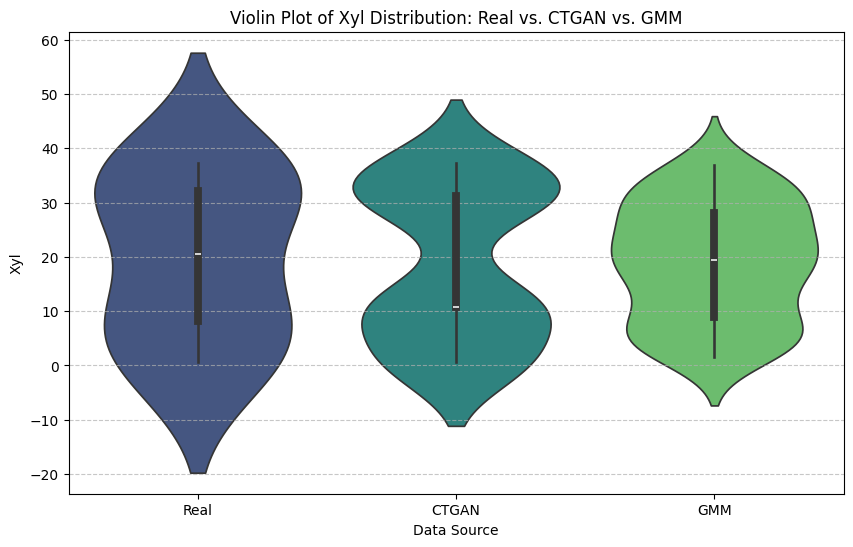

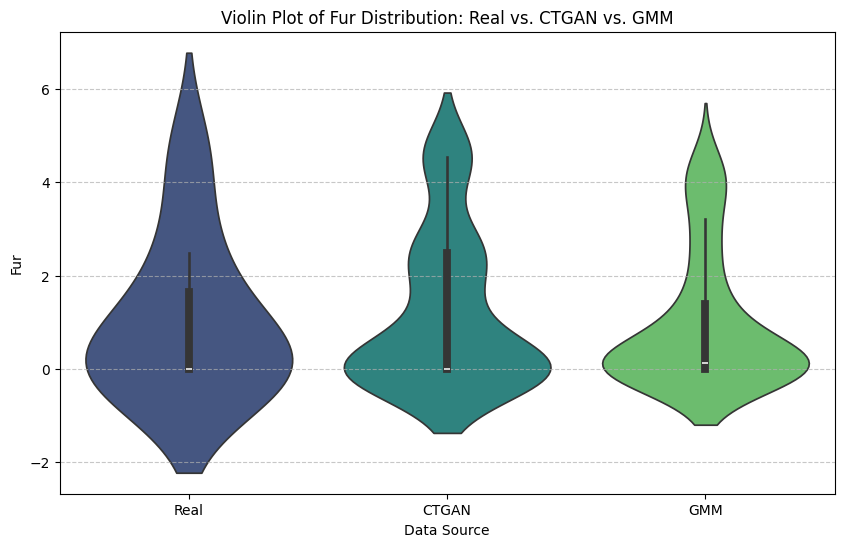

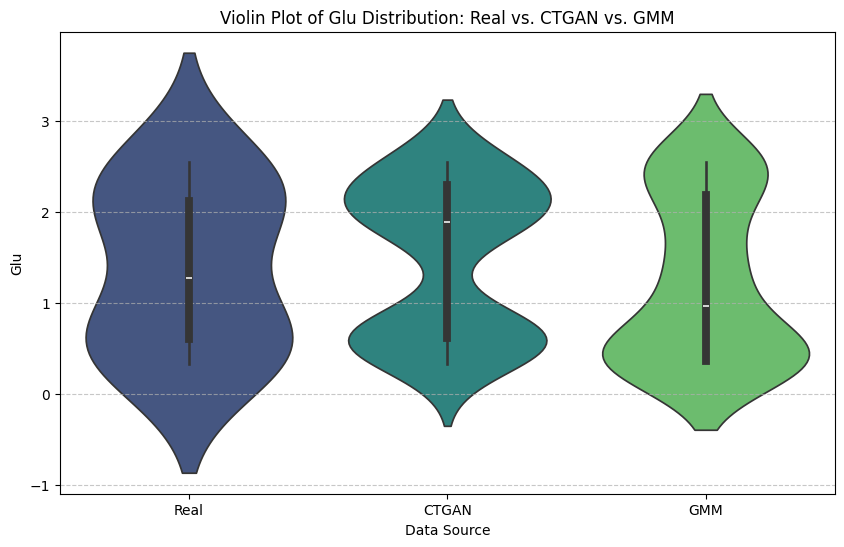

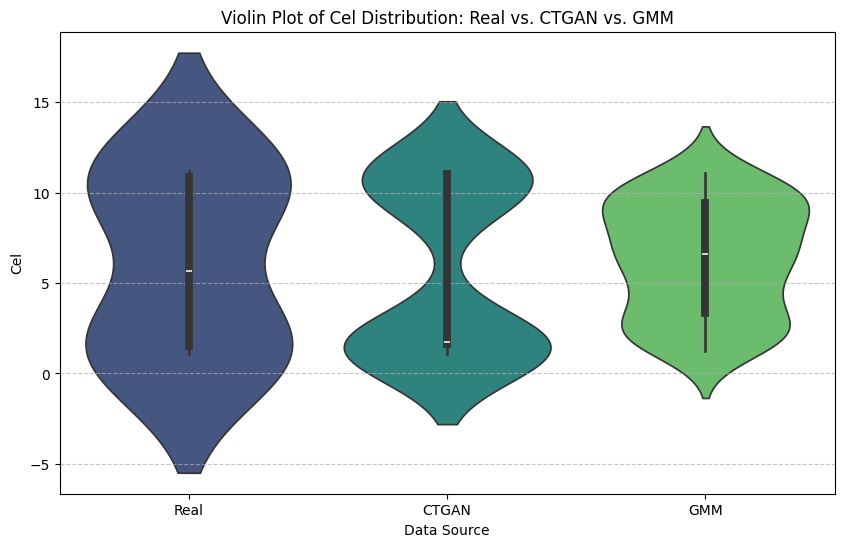

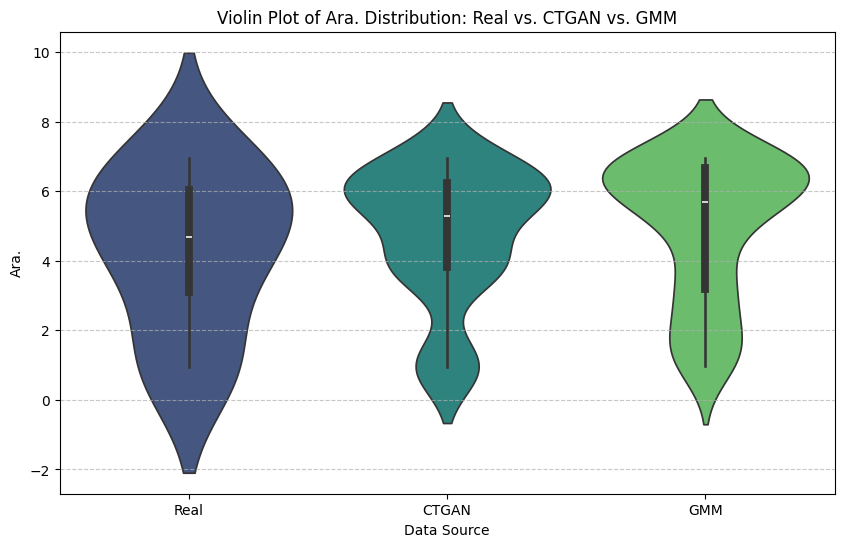

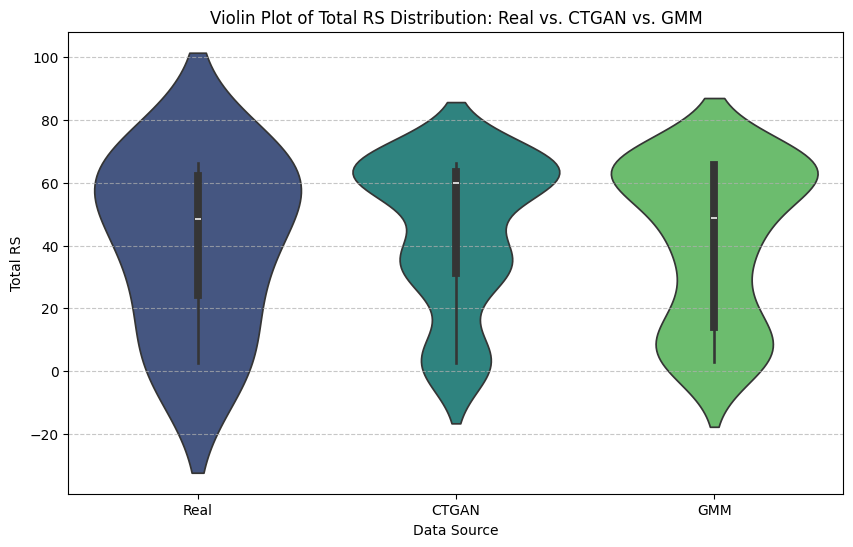

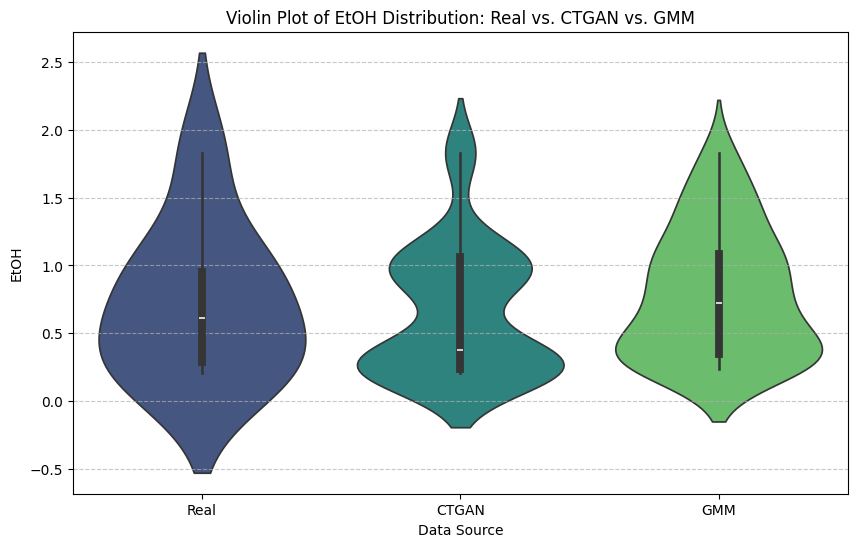

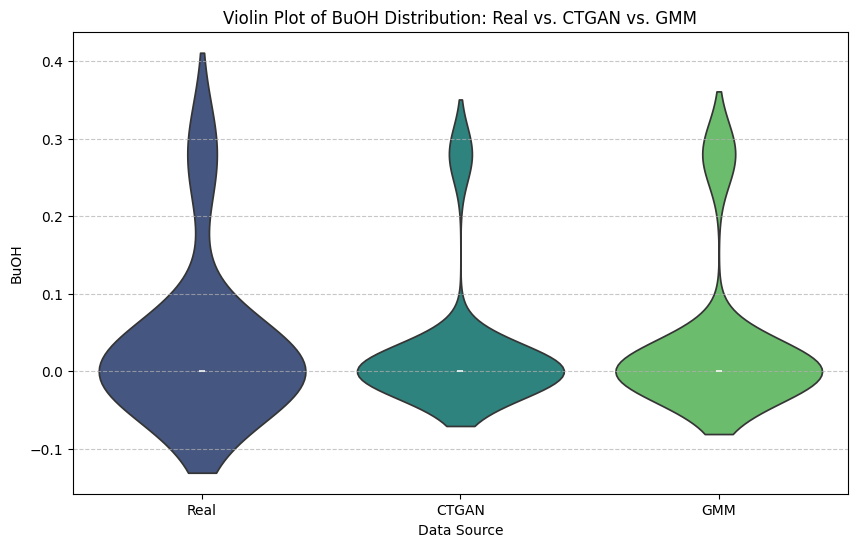

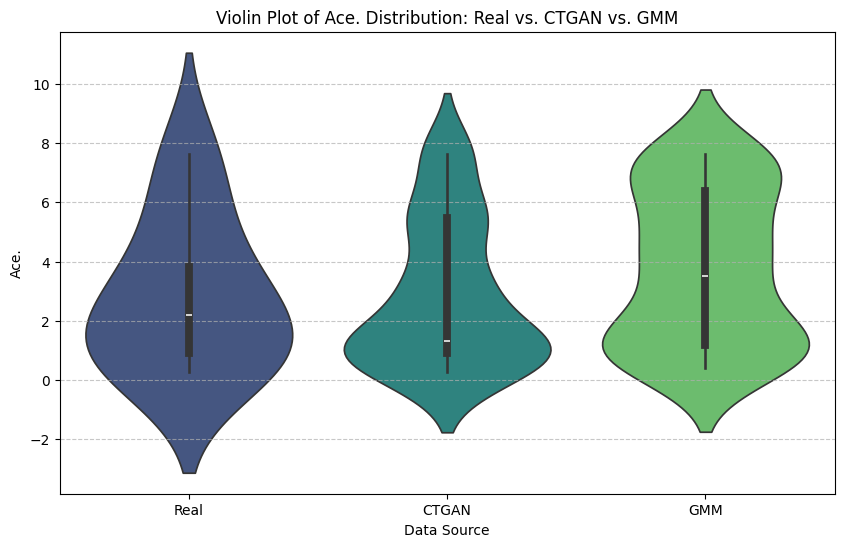

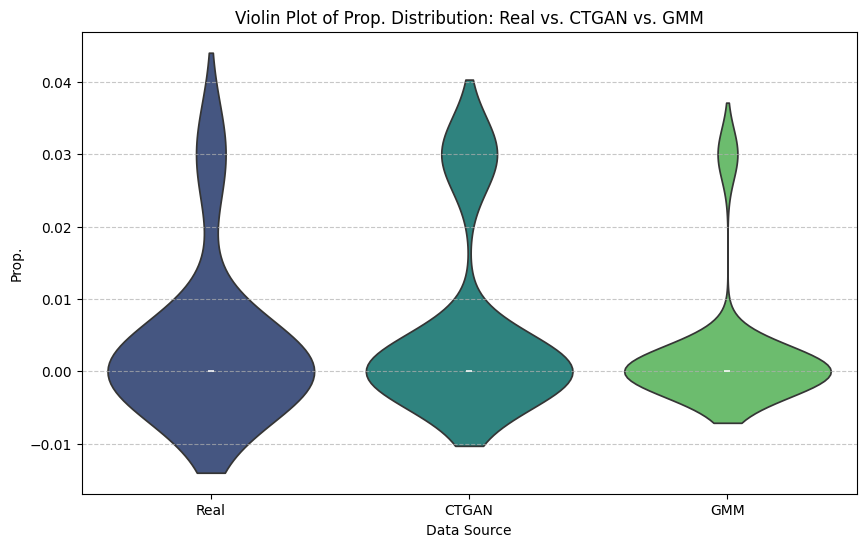

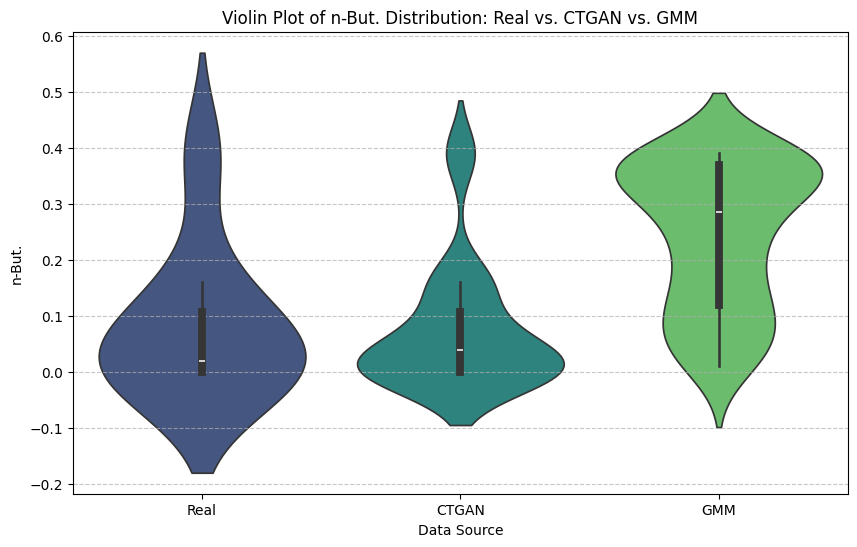

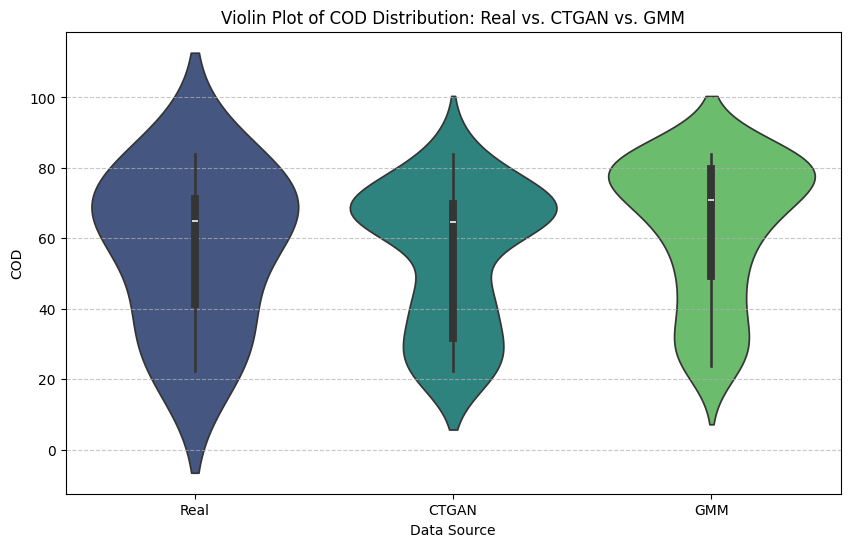

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of columns to plot
columns_to_plot = ['Catalyst', 'samples', 'Xyl', 'Fur', 'Glu', 'Cel', 'Ara.', 'Total RS', 'EtOH', 'BuOH', 'Ace.', 'Prop.', 'n-But.', 'COD']

for column in columns_to_plot:
    # Create a combined DataFrame for the current column
    df_combined = pd.DataFrame({
        column: real_data[column],
        'Source': 'Real'
    })
    df_combined = pd.concat([
        df_combined,
        pd.DataFrame({
            column: synthetic_data_from_ctgan[column],
            'Source': 'CTGAN'
        })
    ])
    df_combined = pd.concat([
        df_combined,
        pd.DataFrame({
            column: synthetic_data_from_gmm[column],
            'Source': 'GMM'
        })
    ])

    # Create the violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Source', y=column, data=df_combined, hue='Source', palette='viridis', legend=False)
    plt.title(f'Violin Plot of {column} Distribution: Real vs. CTGAN vs. GMM')
    plt.xlabel('Data Source')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Skewness and Kurtosis Statistics

In [34]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Redefine numerical_columns to exclude only the truly categorical features
# Assuming 'Catalyst' and 'samples' are the only purely categorical columns
# for which skewness/kurtosis are not applicable.
all_columns = real_data.columns.tolist()
numerical_columns = [col for col in all_columns if col not in ['Catalyst', 'samples']]

def calculate_distribution_stats(dataframe, name):
    stats_df = pd.DataFrame(columns=['Skewness', 'Kurtosis'])
    for col in numerical_columns:
        if col in dataframe.columns:
            col_data = dataframe[col]
            # Only calculate if there's enough data and it's not all constant
            if len(col_data.dropna()) > 1 and col_data.nunique() > 1:
                stats_df.loc[col] = [skew(col_data.dropna()), kurtosis(col_data.dropna())]
            else:
                stats_df.loc[col] = [float('nan'), float('nan')] # Mark as NaN if not computable
        else:
             stats_df.loc[col] = [float('nan'), float('nan')] # Column not found
    print(f"\n--- {name} ---")
    display(stats_df)

# Calculate and display stats for Real Data
calculate_distribution_stats(real_data, 'Real Data')

# Calculate and display stats for CTGAN Synthetic Data
calculate_distribution_stats(synthetic_data_from_ctgan, 'CTGAN Synthetic Data')

# Calculate and display stats for GMM Synthetic Data
calculate_distribution_stats(synthetic_data_from_gmm, 'GMM Synthetic Data')


--- Real Data ---


,Skewness,Kurtosis
Xyl,-0.120673,-1.698932
Fur,1.271749,0.224806
Glu,0.092665,-1.775719
Cel,0.018935,-1.964400
Ara.,-0.514535,-1.153980
Total RS,-0.510558,-1.334011
EtOH,0.914228,-0.170414
BuOH,2.267787,3.142857
Ace.,0.824243,-0.589963
Prop.,2.267787,3.142857



--- CTGAN Synthetic Data ---


,Skewness,Kurtosis
Xyl,0.002462,-1.663072
Fur,0.986623,-0.433717
Glu,-0.108618,-1.750450
Cel,0.169824,-1.934588
Ara.,-0.910574,-0.295278
Total RS,-0.744959,-0.854132
EtOH,0.907799,0.034706
BuOH,2.666667,5.111111
Ace.,0.753323,-0.793171
Prop.,1.405604,-0.024276



--- GMM Synthetic Data ---


,Skewness,Kurtosis
Xyl,-0.046848,-1.226455
Fur,1.303913,0.216410
Glu,0.406036,-1.509729
Cel,-0.138949,-1.310422
Ara.,-0.794177,-0.880348
Total RS,-0.464499,-1.437814
EtOH,0.563759,-0.799918
BuOH,2.105267,2.432148
Ace.,0.200401,-1.473294
Prop.,2.919668,6.524462


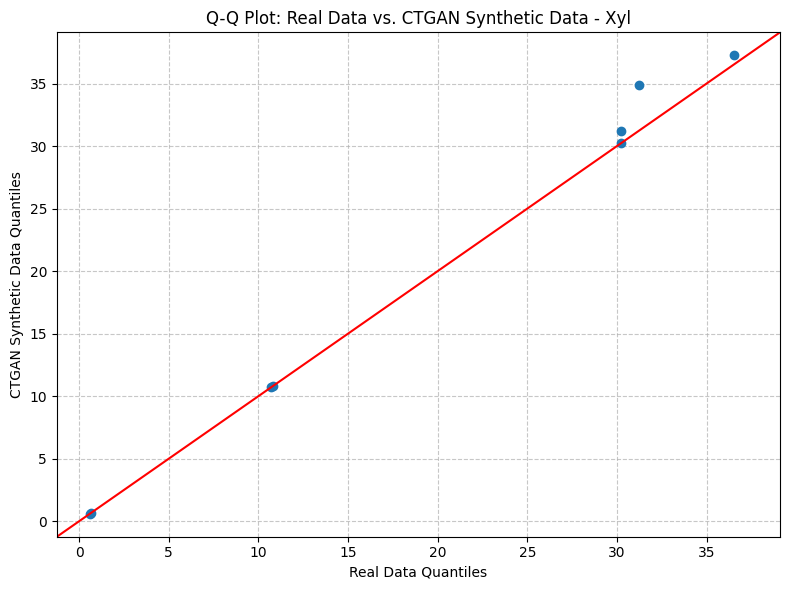

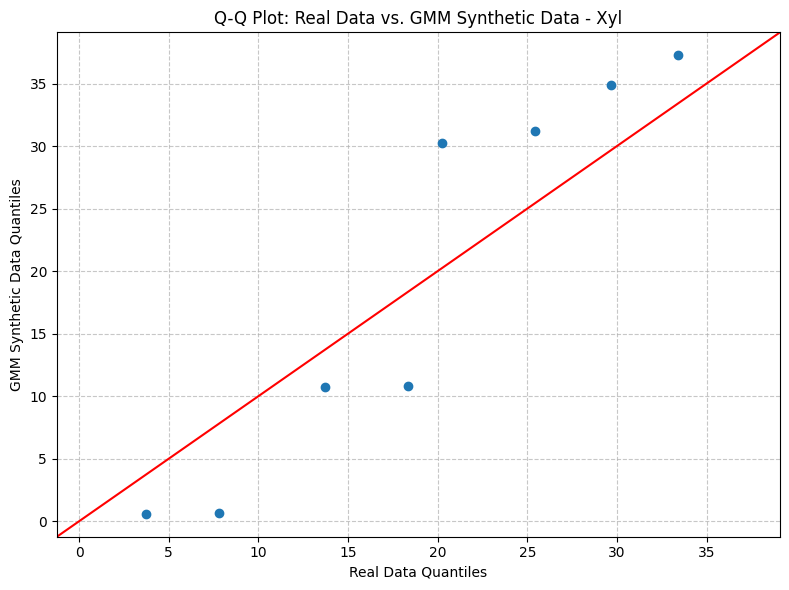

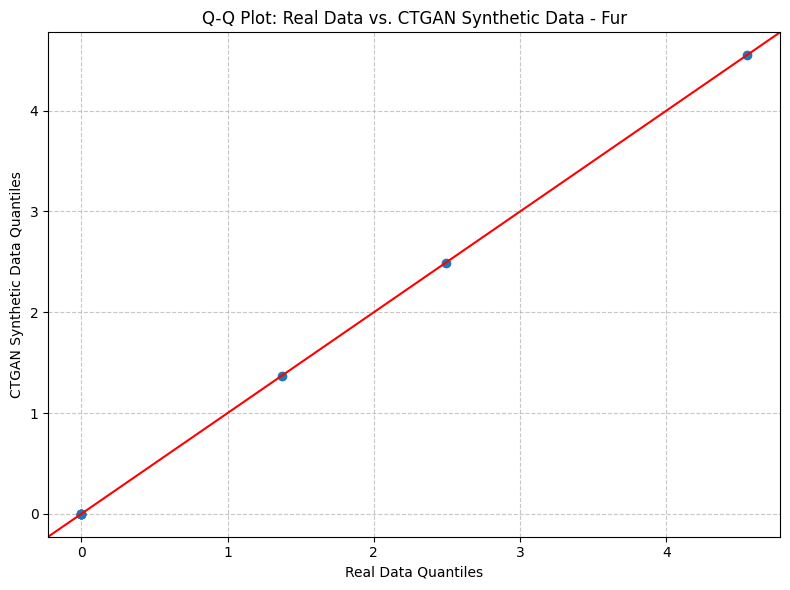

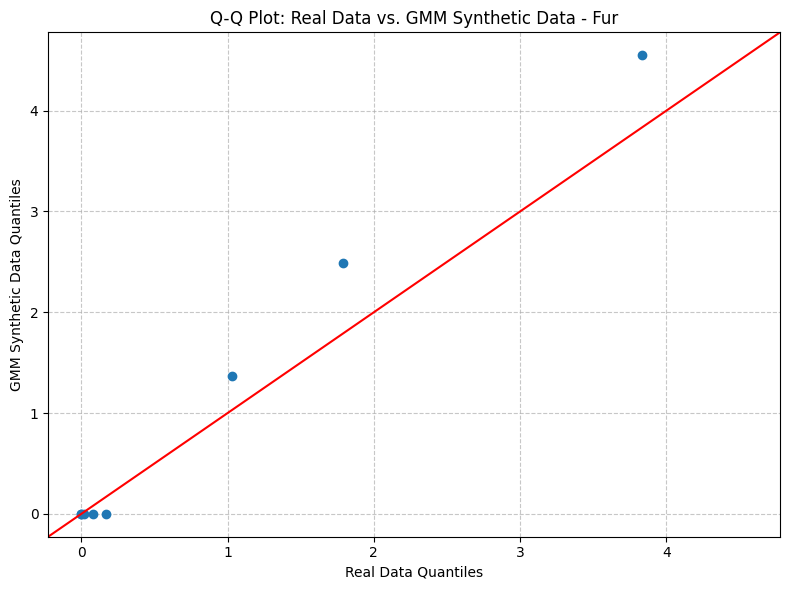

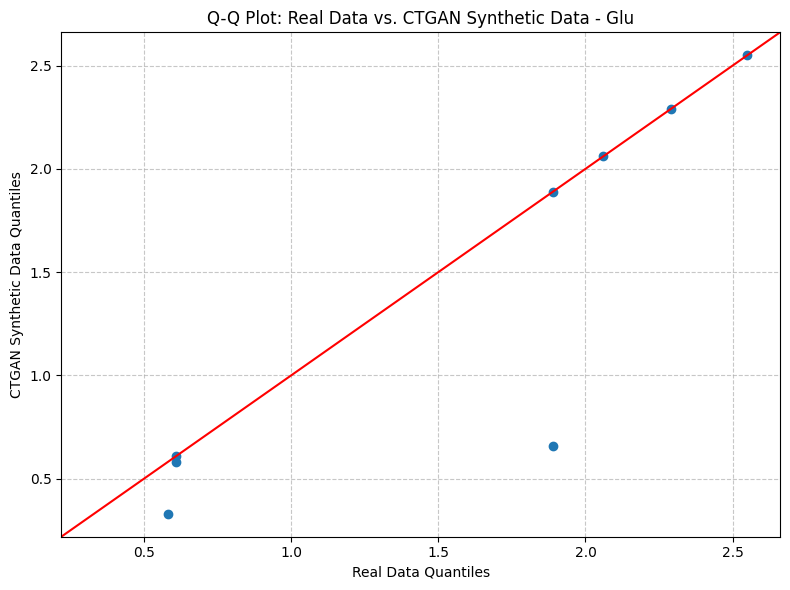

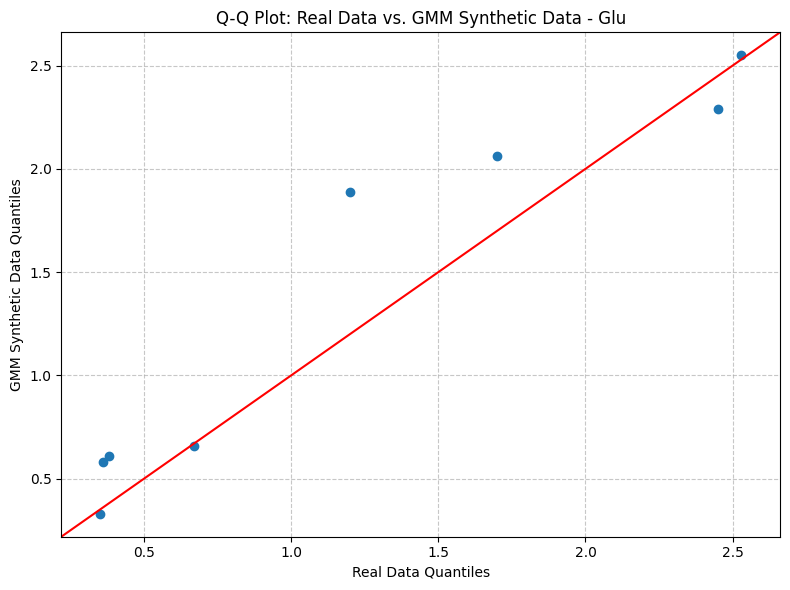

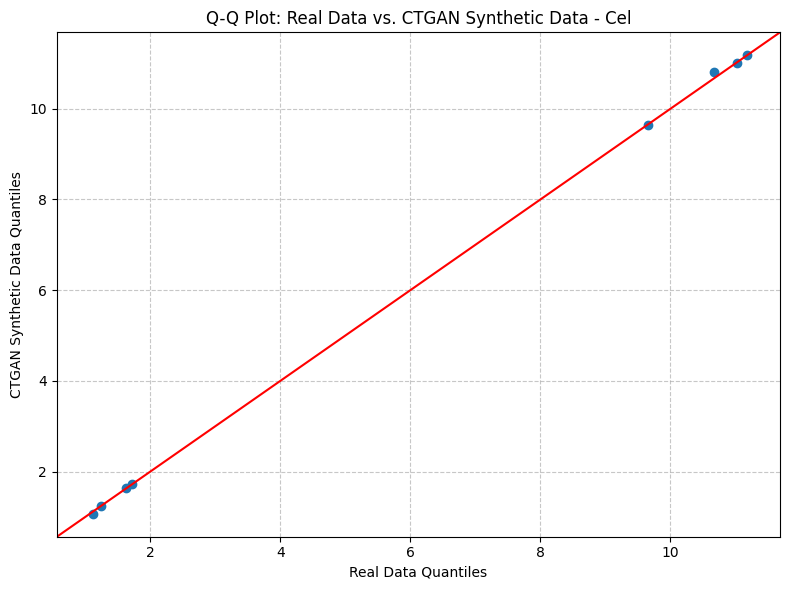

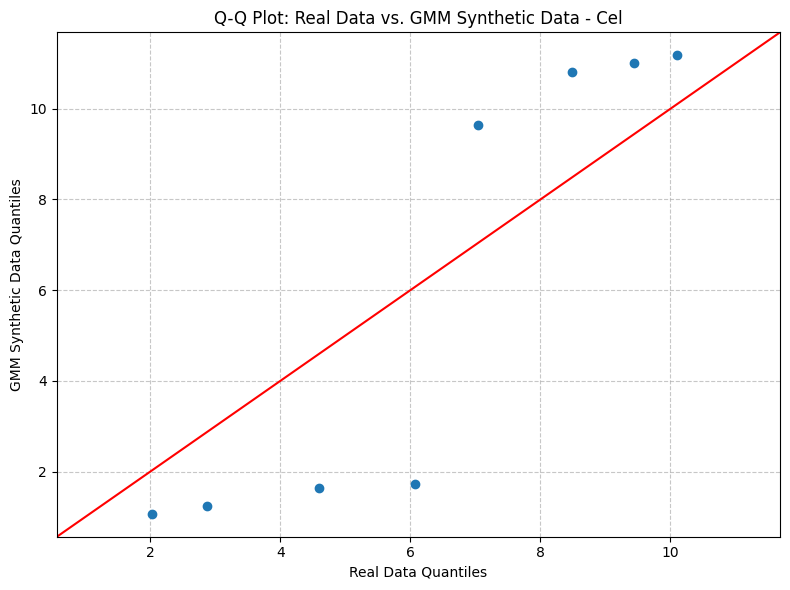

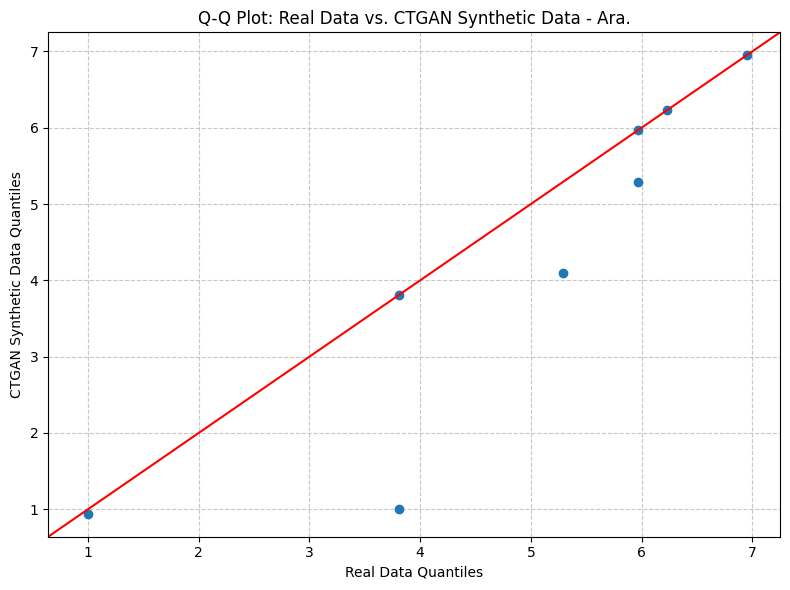

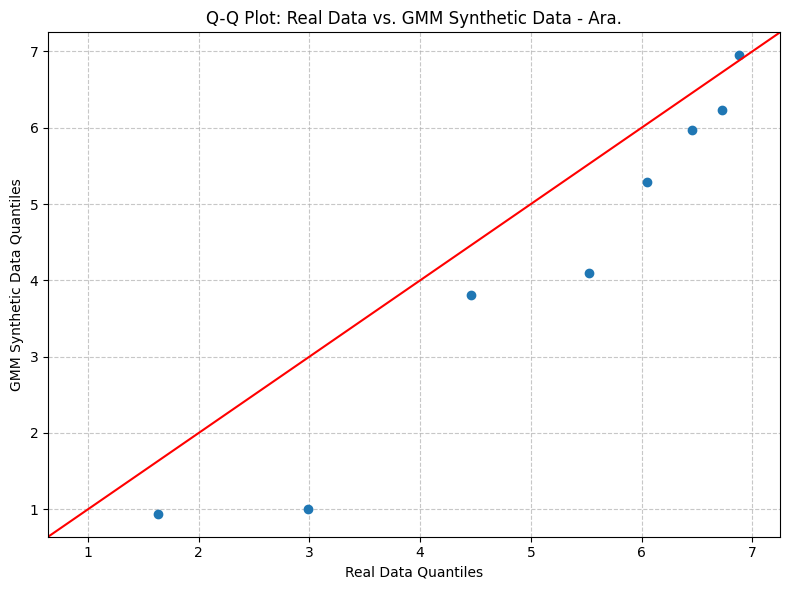

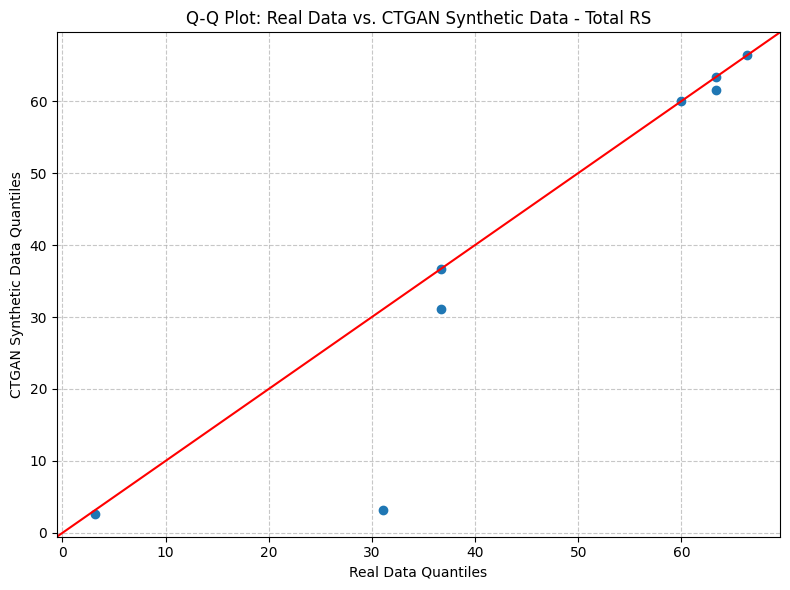

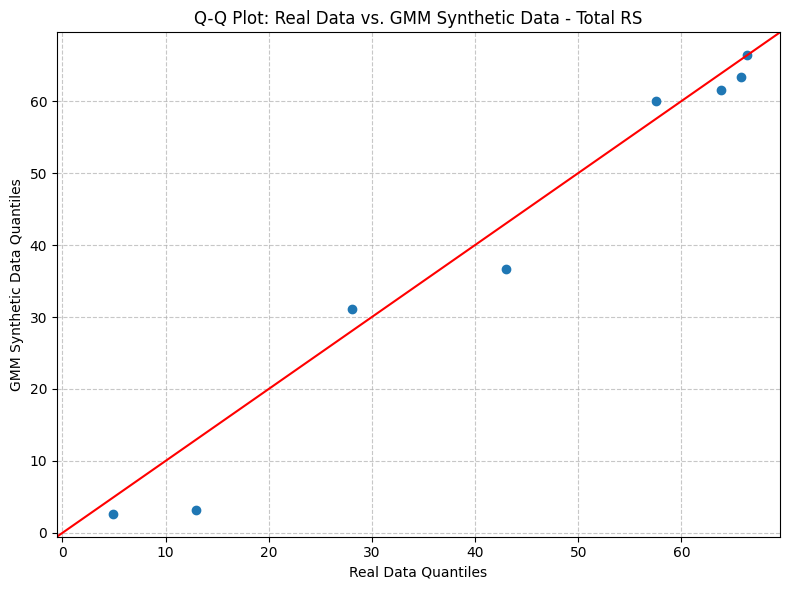

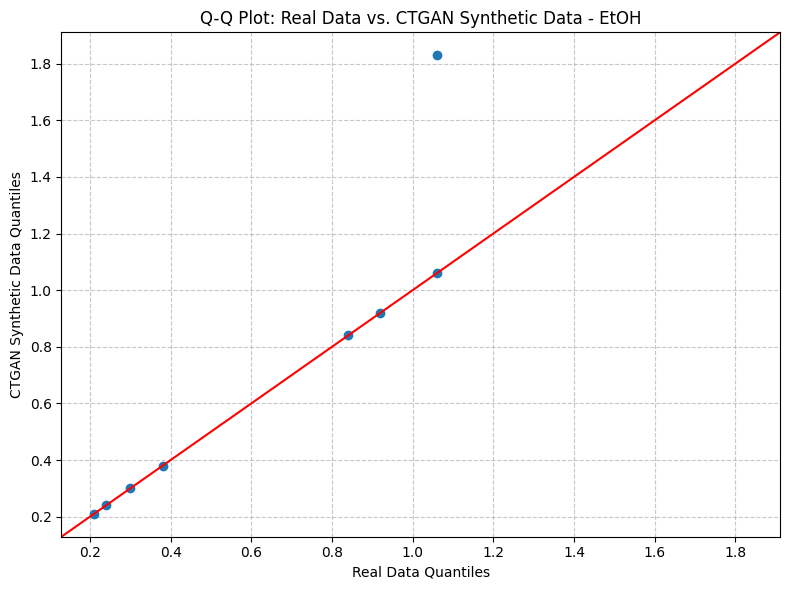

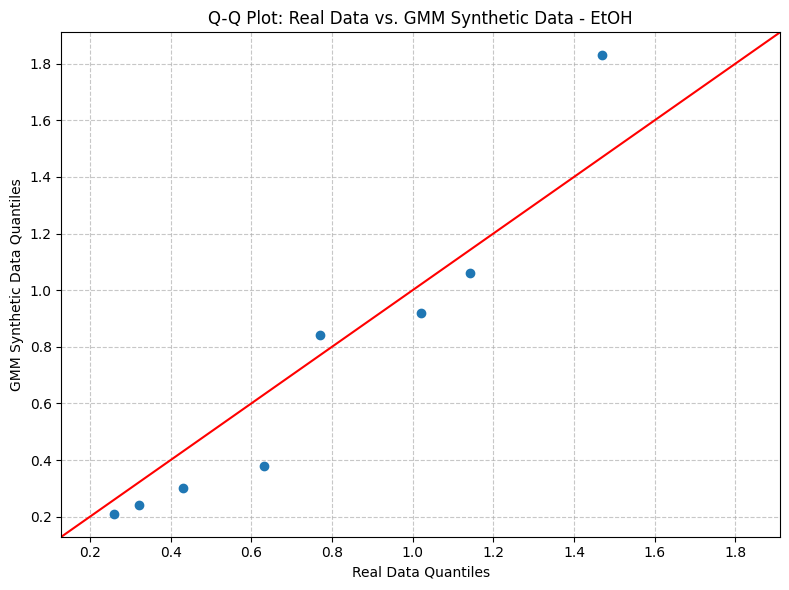

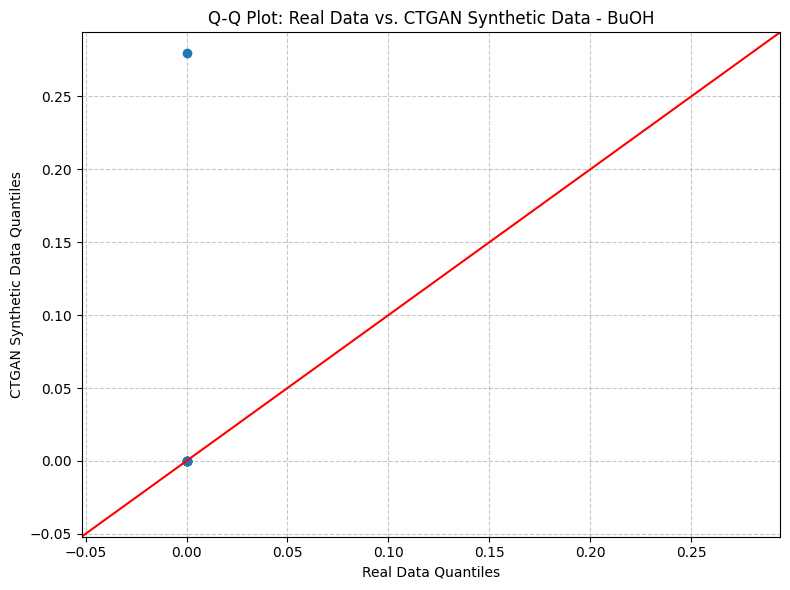

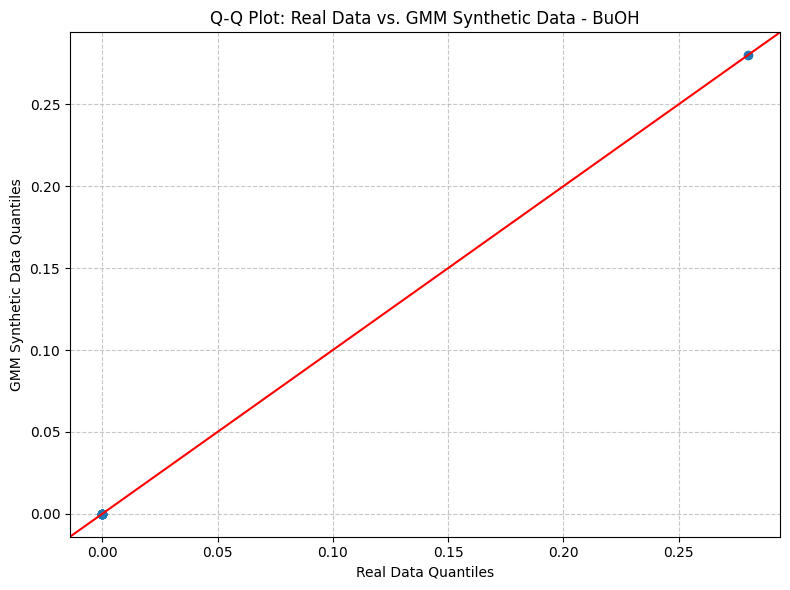

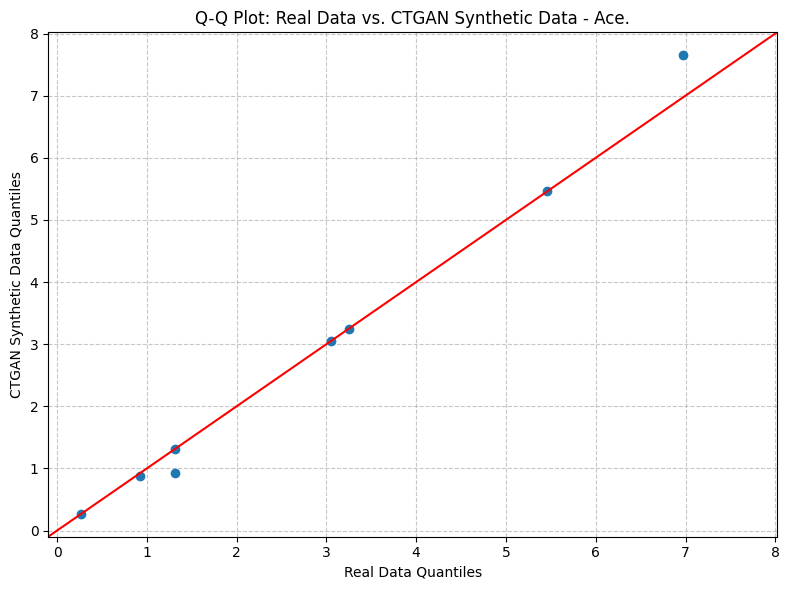

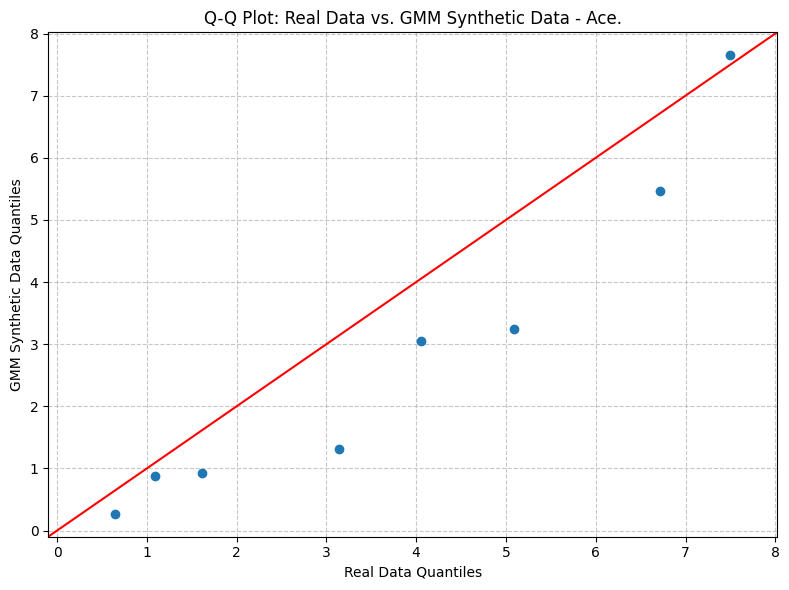

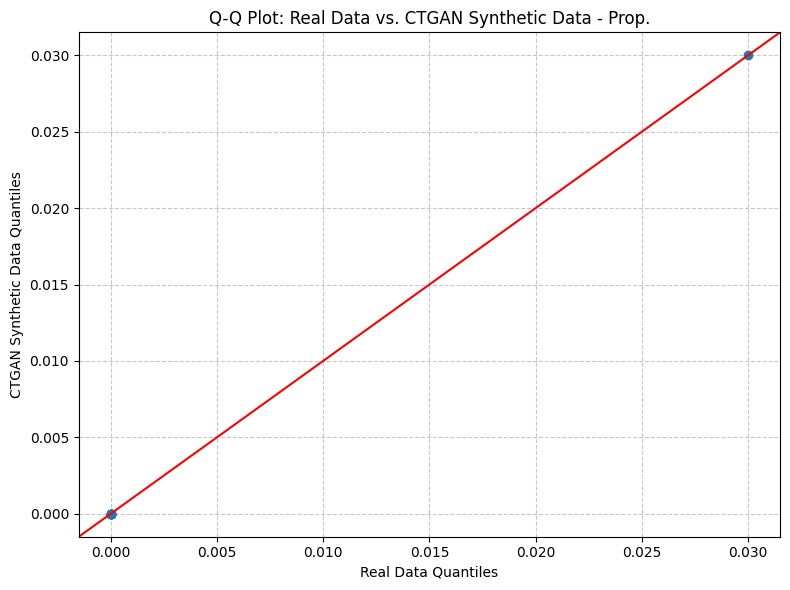

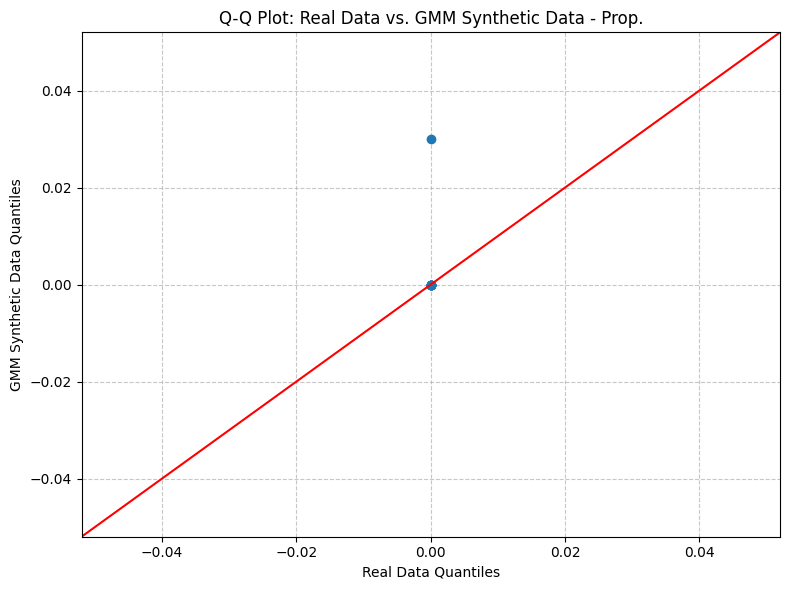

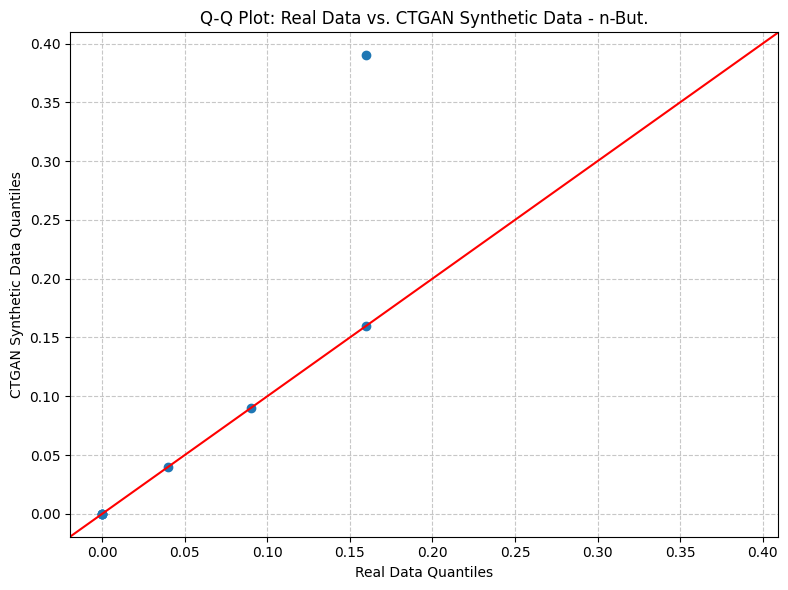

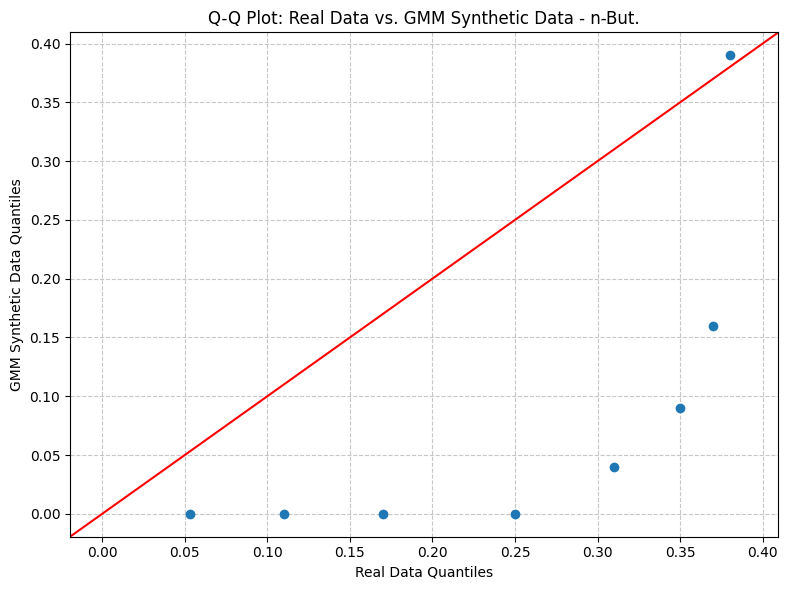

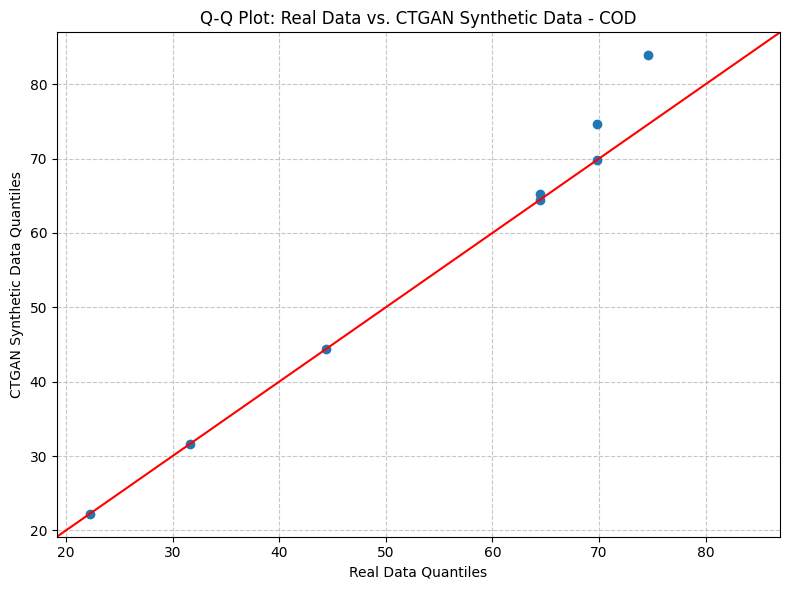

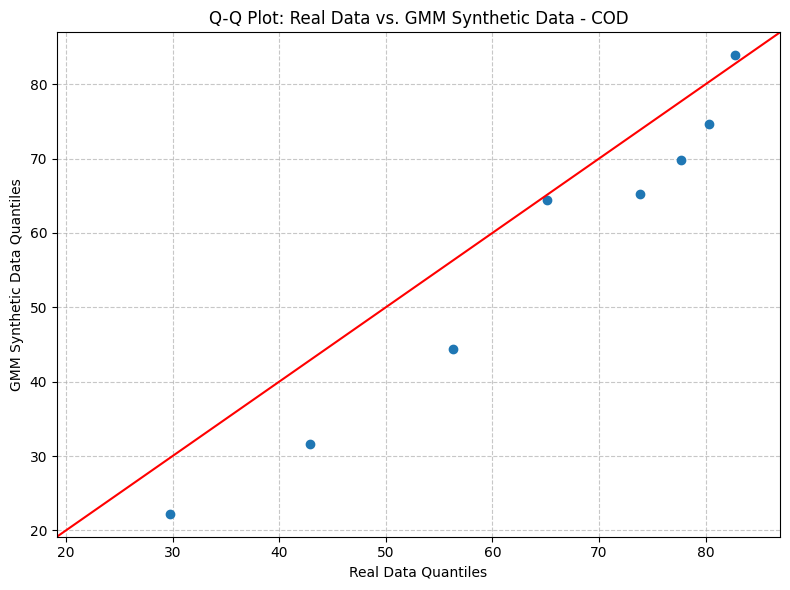

In [37]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# numerical_columns is already defined from previous steps
# For better visualization, we will plot only the columns where Q-Q plot is meaningful
# which are typically continuous numerical columns.

for column in numerical_columns:
    # Q-Q plot for Real vs. CTGAN Synthetic Data
    fig, ax = plt.subplots(figsize=(8, 6))
    # Corrected usage: pass the second dataset to the 'other' argument for empirical-empirical Q-Q plot
    sm.qqplot(real_data[column].dropna(), other=synthetic_data_from_ctgan[column].dropna(), line='45', ax=ax)
    ax.set_title(f'Q-Q Plot: Real Data vs. CTGAN Synthetic Data - {column}')
    ax.set_xlabel('Real Data Quantiles')
    ax.set_ylabel('CTGAN Synthetic Data Quantiles')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Q-Q plot for Real vs. GMM Synthetic Data
    fig, ax = plt.subplots(figsize=(8, 6))
    # Corrected usage: pass the second dataset to the 'other' argument for empirical-empirical Q-Q plot
    sm.qqplot(real_data[column].dropna(), other=synthetic_data_from_gmm[column].dropna(), line='45', ax=ax)
    ax.set_title(f'Q-Q Plot: Real Data vs. GMM Synthetic Data - {column}')
    ax.set_xlabel('Real Data Quantiles')
    ax.set_ylabel('GMM Synthetic Data Quantiles')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## SHAP Analysis for Synthetic Data ('Total RS' as Target)

To further evaluate the synthetic data, we will perform SHAP (SHapley Additive exPlanations) analysis. This will help us understand which features contribute most to the 'Total RS' values in the synthetic datasets, and if these contributions align with what we might expect from the real data.

We will train a surrogate model (RandomForestRegressor) on the synthetic data, with 'Total RS' as the target variable, and then compute SHAP values to explain the model's predictions.

In [1]:
!pip install shap

In [2]:
!pip install Numba

In [5]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Define target and features
target_column = 'Total RS'
categorical_cols_for_model = ['Catalyst', 'samples'] # Only truly categorical for modeling

# Prepare dataframes for modeling (one-hot encode categorical features)
def preprocess_data_for_shap(df, categorical_features_list, target):
    # Drop target column for features
    X = df.drop(columns=[target], errors='ignore')
    y = df[target]

    # Apply one-hot encoding to specified categorical columns
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_encoded = encoder.fit_transform(X[categorical_features_list])
    encoded_feature_names = encoder.get_feature_names_out(categorical_features_list)
    X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names, index=X.index)

    # Drop original categorical columns and concatenate encoded ones
    X_numeric = X.drop(columns=categorical_features_list)
    X_processed = pd.concat([X_numeric, X_encoded_df], axis=1)

    return X_processed, y, encoder

# --- SHAP Analysis for CTGAN Synthetic Data ---
print("\n--- SHAP Analysis for CTGAN Synthetic Data ---")

X_ctgan_processed, y_ctgan, ctgan_encoder = preprocess_data_for_shap(synthetic_data_from_ctgan, categorical_cols_for_model, target_column)

# Train a RandomForestRegressor on the CTGAN synthetic data
ctgan_model = RandomForestRegressor(n_estimators=100, random_state=42)
ctgan_model.fit(X_ctgan_processed, y_ctgan)

# Explain the model's predictions using SHAP
ctgan_explainer = shap.TreeExplainer(ctgan_model)
ctgan_shap_values = ctgan_explainer.shap_values(X_ctgan_processed)

# --- SHAP Analysis for GMM Synthetic Data ---
print("\n--- SHAP Analysis for GMM Synthetic Data ---")

X_gmm_processed, y_gmm, gmm_encoder = preprocess_data_for_shap(synthetic_data_from_gmm, categorical_cols_for_model, target_column)

# Train a RandomForestRegressor on the GMM synthetic data
gmm_model = RandomForestRegressor(n_estimators=100, random_state=42)
gmm_model.fit(X_gmm_processed, y_gmm)

# Explain the model's predictions using SHAP
gmm_explainer = shap.TreeExplainer(gmm_model)
gmm_shap_values = gmm_explainer.shap_values(X_gmm_processed)


--- SHAP Analysis for CTGAN Synthetic Data ---


NameError: name 'synthetic_data_from_ctgan' is not defined

### Comparing Average Skewness and Kurtosis Errors Across Models

In [35]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Redefine numerical_columns to exclude only the truly categorical features
# Assuming 'Catalyst' and 'samples' are the only purely categorical columns
# for which skewness/kurtosis are not applicable.
all_columns = real_data.columns.tolist()
numerical_columns = [col for col in all_columns if col not in ['Catalyst', 'samples']]

def get_distribution_stats_df(dataframe):
    stats_df = pd.DataFrame(columns=['Skewness', 'Kurtosis'])
    for col in numerical_columns:
        if col in dataframe.columns:
            col_data = dataframe[col]
            if len(col_data.dropna()) > 1 and col_data.nunique() > 1:
                stats_df.loc[col] = [skew(col_data.dropna()), kurtosis(col_data.dropna())]
            else:
                stats_df.loc[col] = [float('nan'), float('nan')]
        else:
             stats_df.loc[col] = [float('nan'), float('nan')]
    return stats_df

# Get stats for each dataset
stats_real = get_distribution_stats_df(real_data)
stats_ctgan = get_distribution_stats_df(synthetic_data_from_ctgan)
stats_gmm = get_distribution_stats_df(synthetic_data_from_gmm)

# Calculate absolute errors for Skewness
skewness_error_ctgan = (stats_ctgan['Skewness'] - stats_real['Skewness']).abs()
skewness_error_gmm = (stats_gmm['Skewness'] - stats_real['Skewness']).abs()

# Calculate absolute errors for Kurtosis
kurtosis_error_ctgan = (stats_ctgan['Kurtosis'] - stats_real['Kurtosis']).abs()
kurtosis_error_gmm = (stats_gmm['Kurtosis'] - stats_real['Kurtosis']).abs()

# Calculate average absolute errors, ignoring NaN values
mean_skewness_error_ctgan = skewness_error_ctgan.mean(skipna=True)
mean_kurtosis_error_ctgan = kurtosis_error_ctgan.mean(skipna=True)

mean_skewness_error_gmm = skewness_error_gmm.mean(skipna=True)
mean_kurtosis_error_gmm = kurtosis_error_gmm.mean(skipna=True)

# Display the results
comparison_df = pd.DataFrame({
    'Metric': ['Skewness Error (Mean Absolute)', 'Kurtosis Error (Mean Absolute)']
})
comparison_df['CTGAN'] = [mean_skewness_error_ctgan, mean_kurtosis_error_ctgan]
comparison_df['GMM'] = [mean_skewness_error_gmm, mean_kurtosis_error_gmm]

print("\nAverage Absolute Skewness and Kurtosis Errors:")
display(comparison_df)


Average Absolute Skewness and Kurtosis Errors:


,Metric,CTGAN,GMM
0,Skewness Error (Mean Absolute),0.245127,0.416431
1,Kurtosis Error (Mean Absolute),0.735295,0.852140


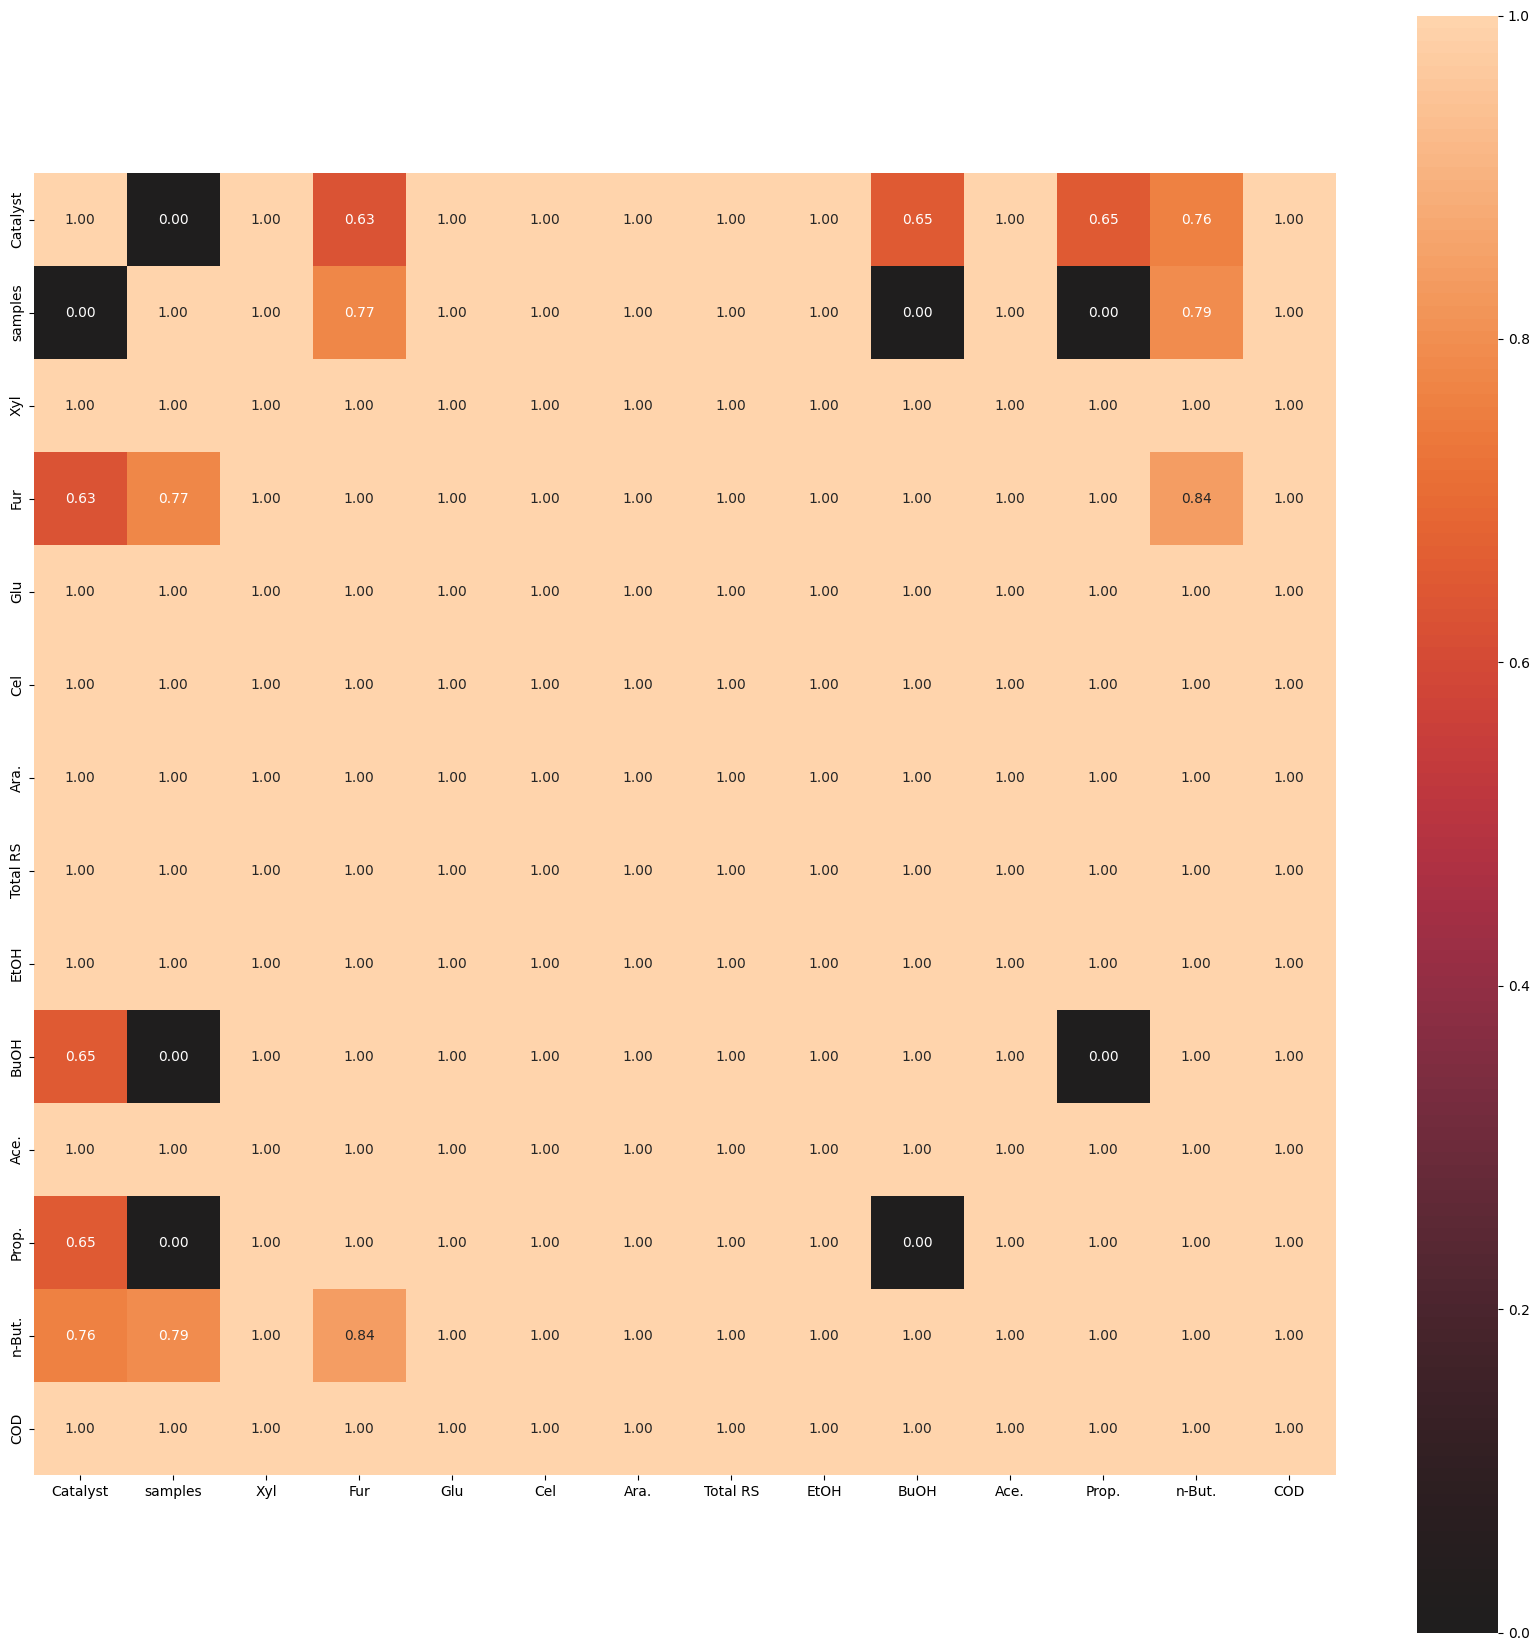

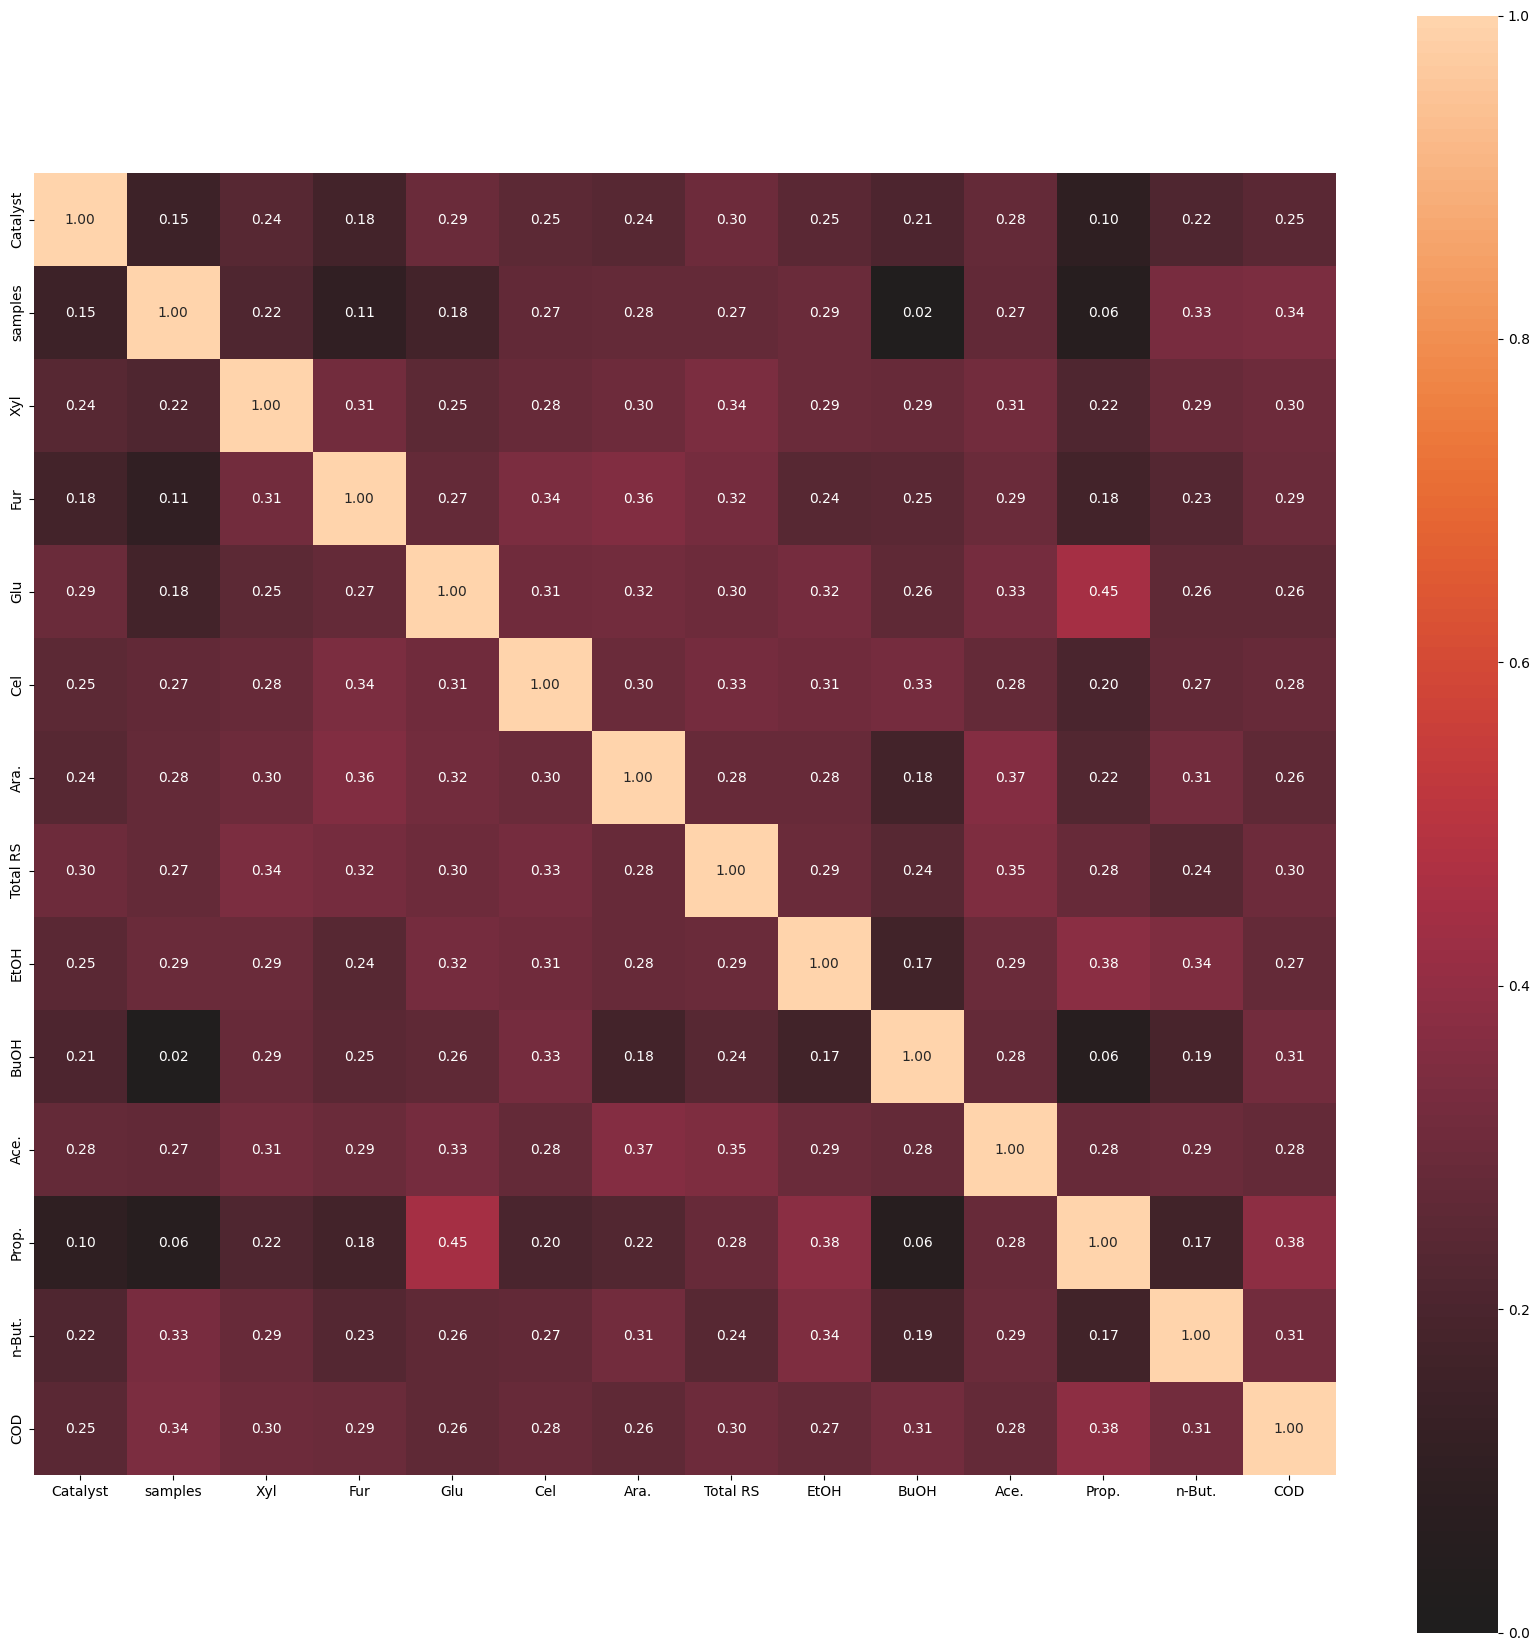

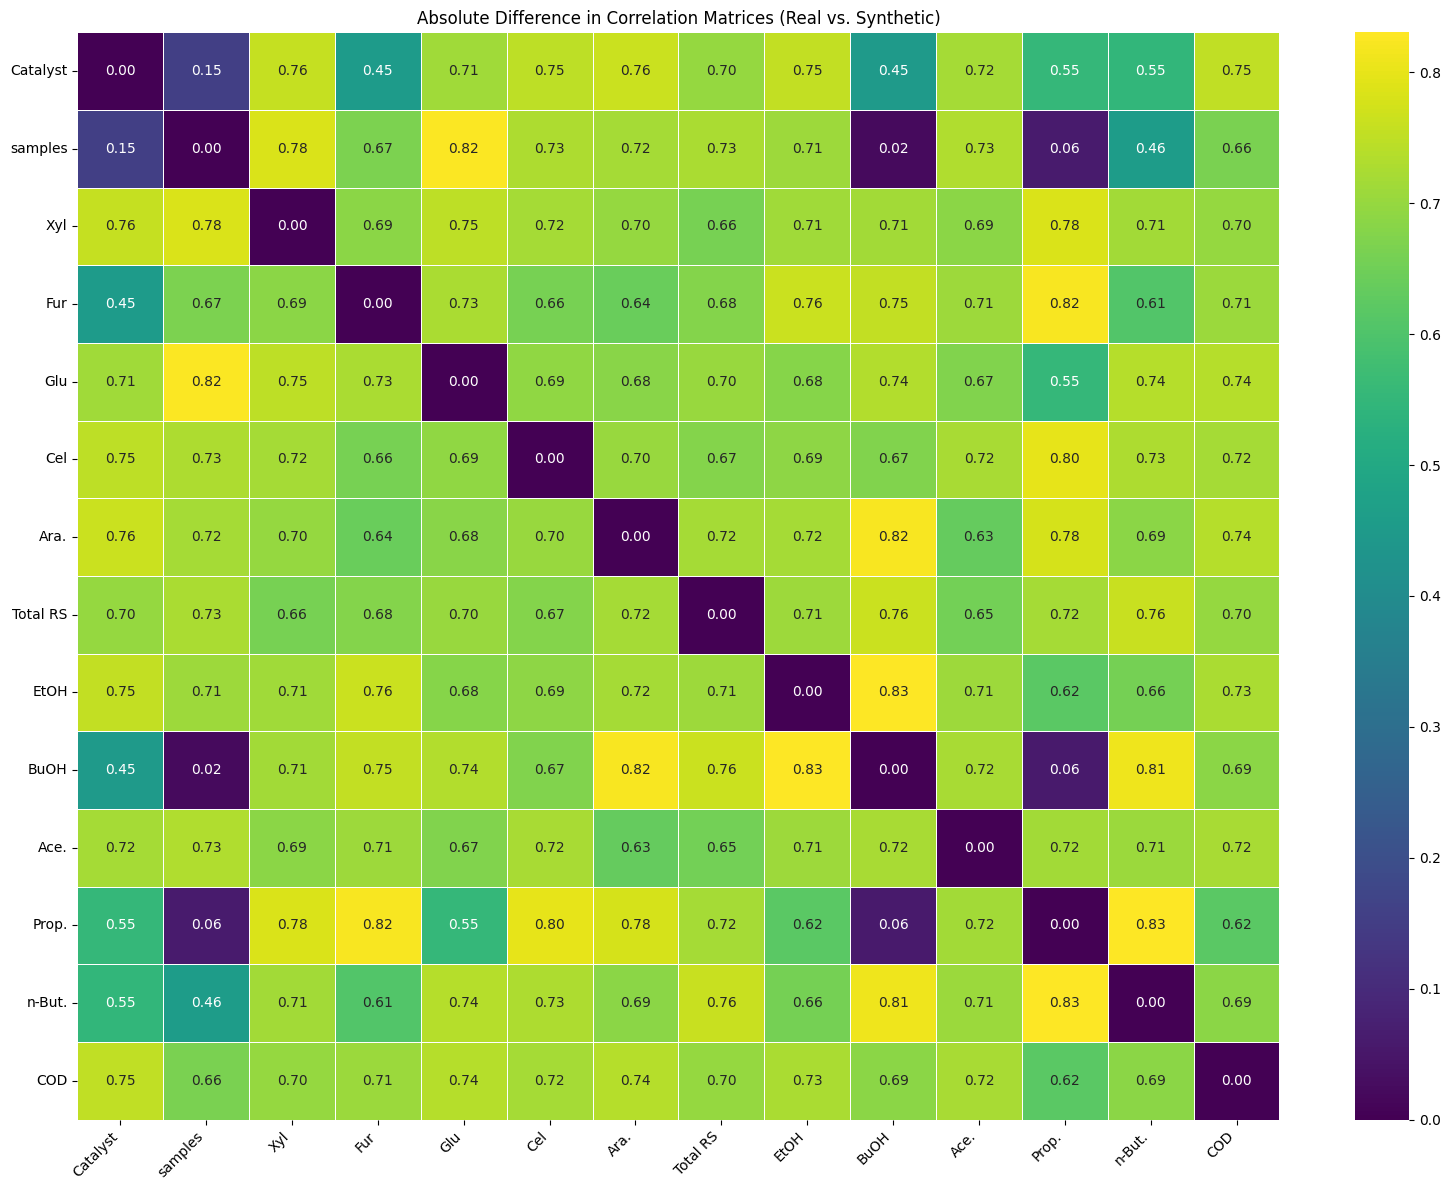

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

# Calculate correlation matrix for real data
real_correlation_matrix = associations(real_data, nominal_columns=categorical_features, plot=False, cramers_v_bias_correction=False)['corr']

# Calculate correlation matrix for synthetic data
synthetic_correlation_matrix = associations(synthetic_data_from_ctgan, nominal_columns=categorical_features, plot=False, cramers_v_bias_correction=False)['corr']

# Calculate the absolute difference between the two correlation matrices
# Fill NaN values with 0 before subtraction to handle cases where associations might not be computable for some pairs
correlation_difference = (real_correlation_matrix.fillna(0) - synthetic_correlation_matrix.fillna(0)).abs()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_difference, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Absolute Difference in Correlation Matrices (Real vs. Synthetic)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan, # Corrected to use CTGAN synthetic data
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 14/14 [00:00<00:00, 357.60it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 71.52it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

(8, 14) (100, 14)


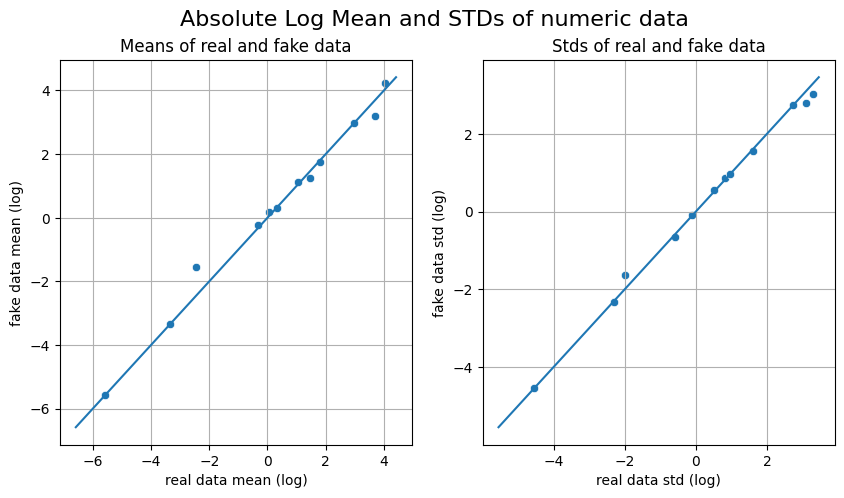

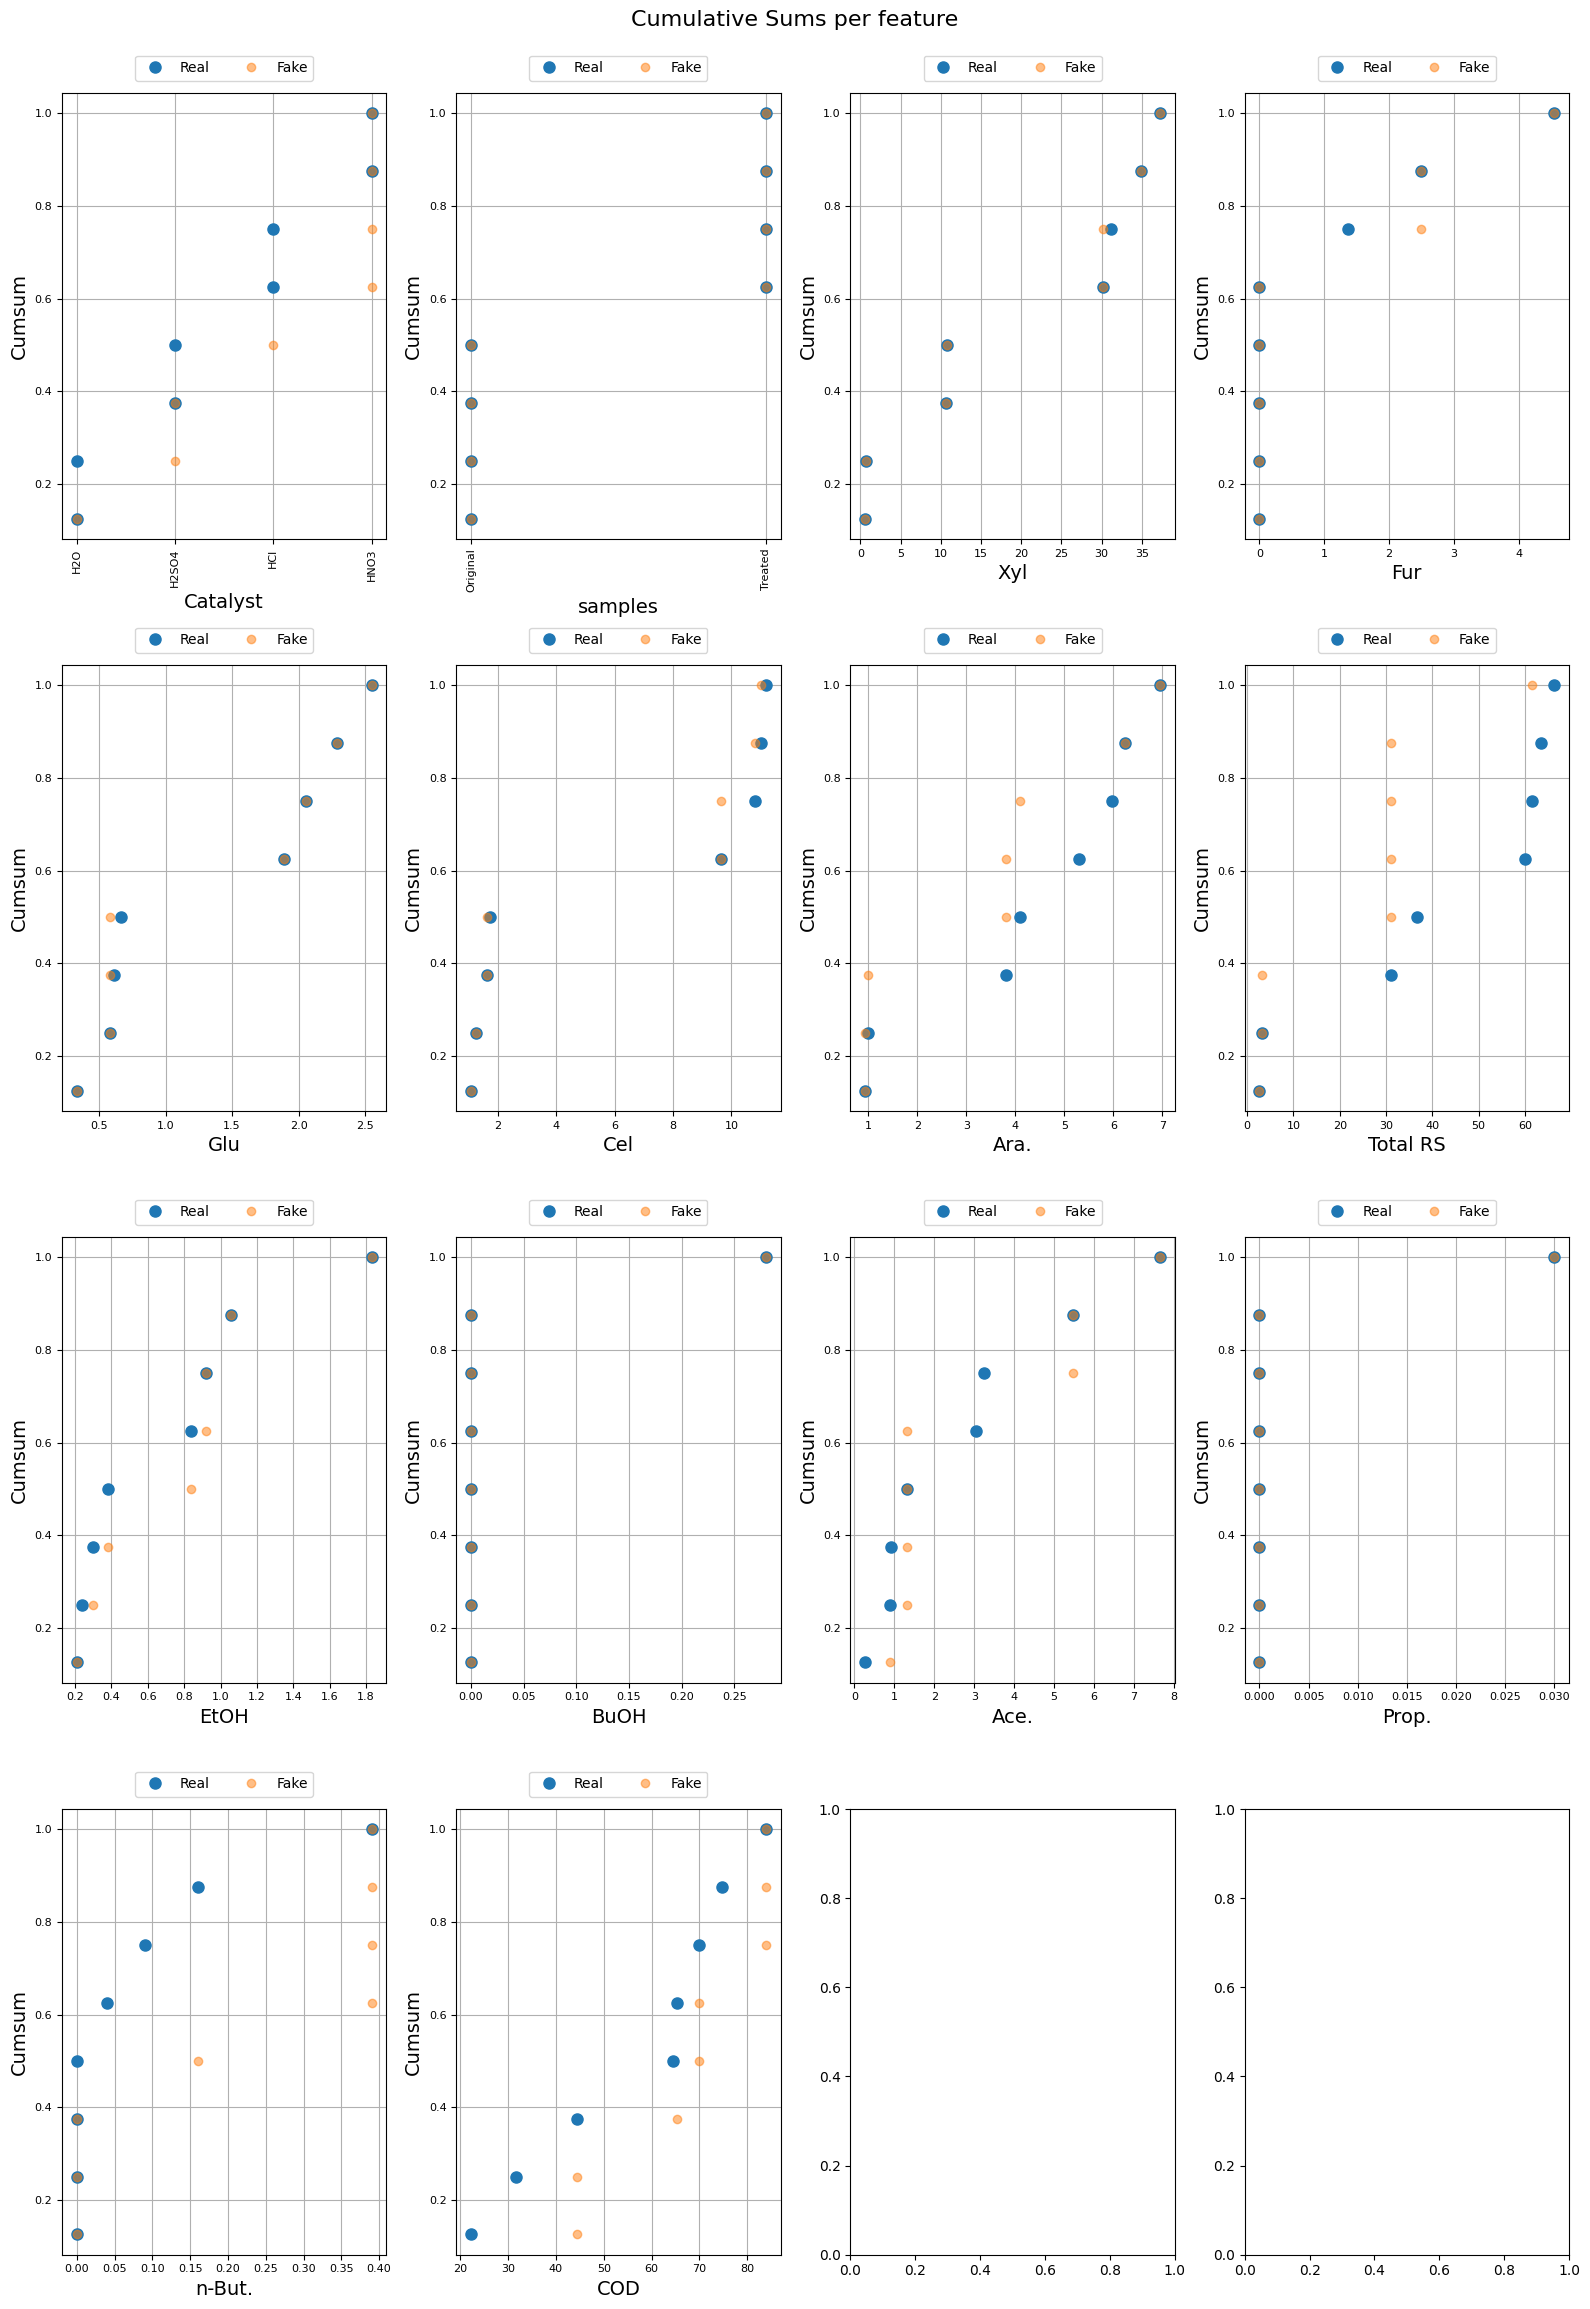

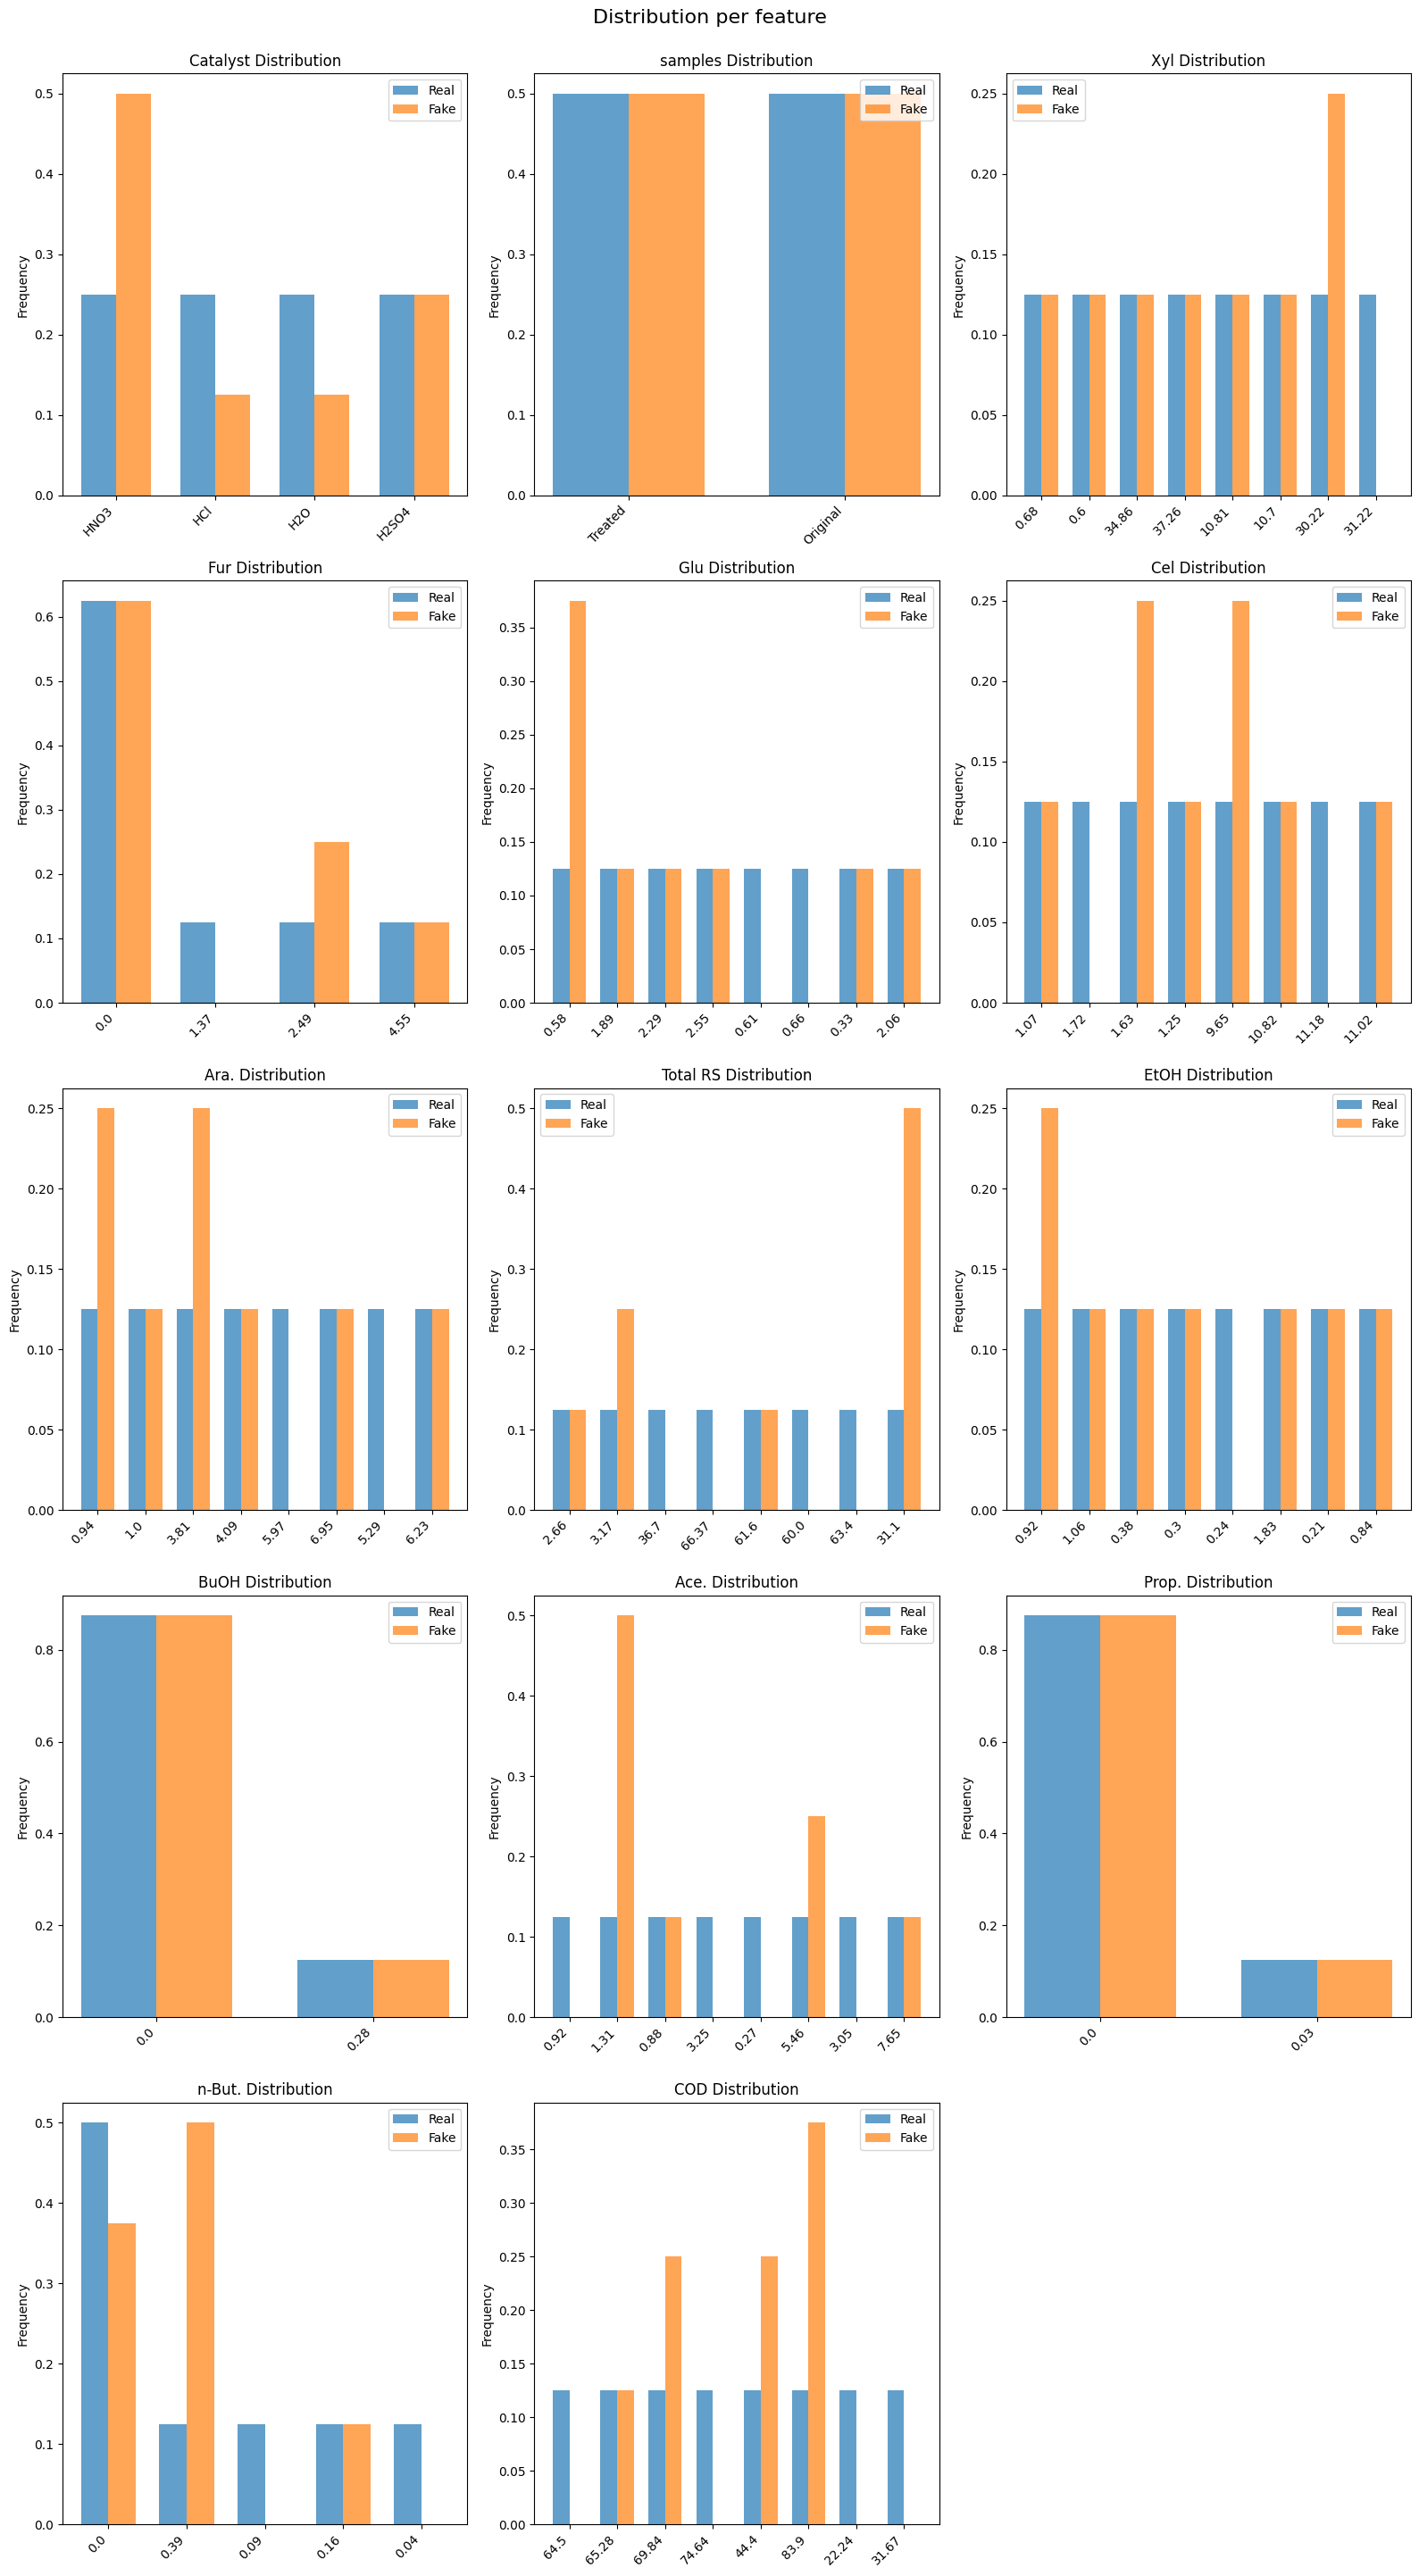

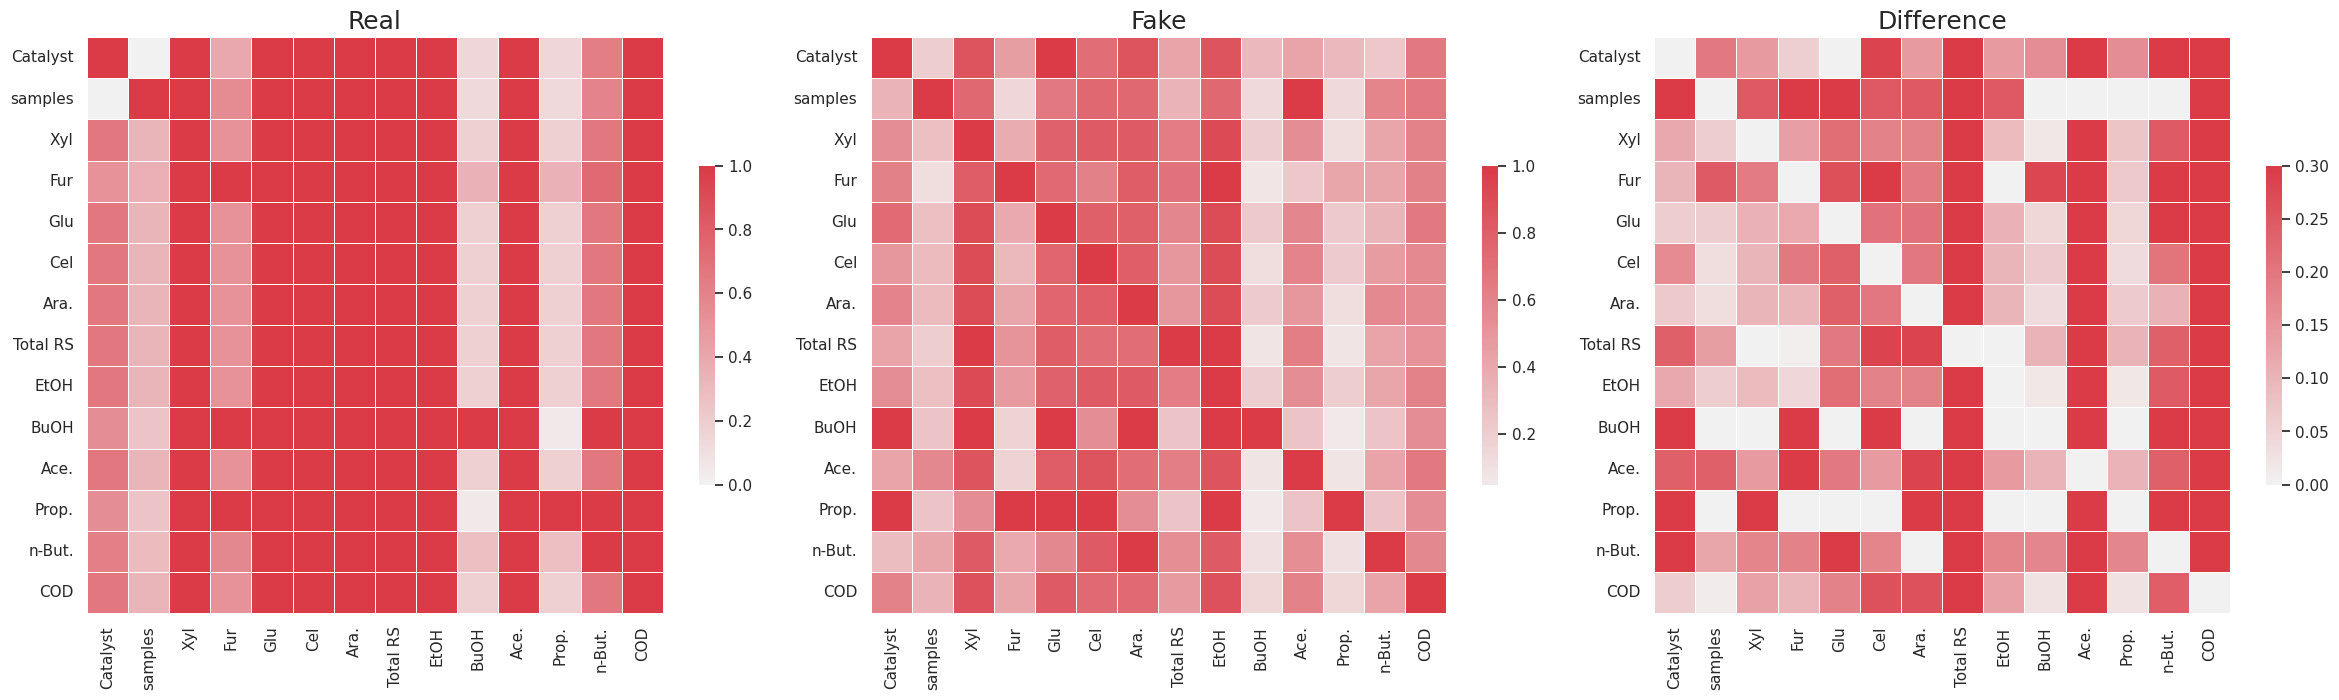

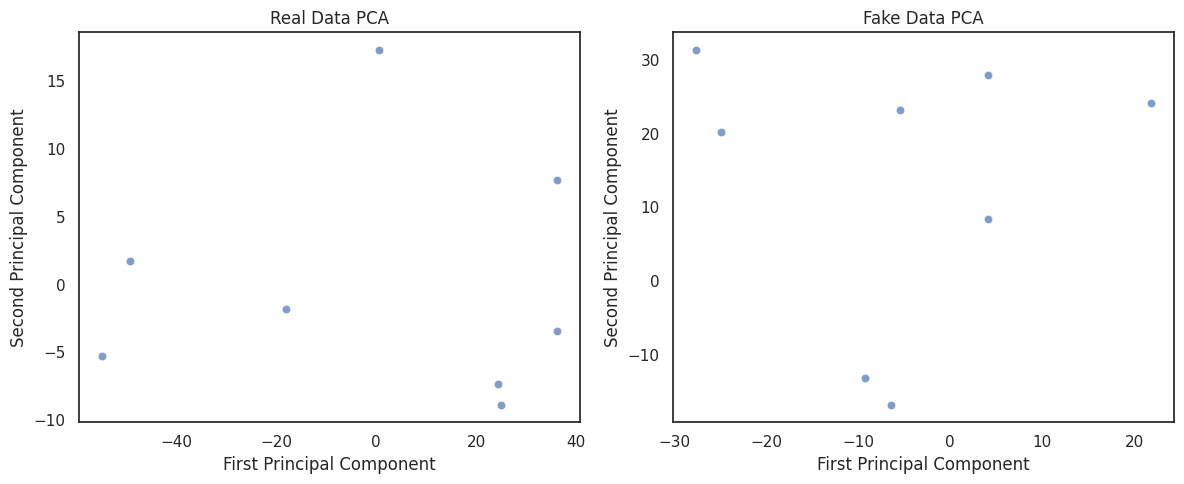

In [63]:
from table_evaluator import TableEvaluator
print(real_data.shape, samples.shape) # Corrected print statement
table_evaluator = TableEvaluator(real_data.copy(), samples.copy(), categorical_features)
table_evaluator.visual_evaluation()

In [65]:
display(real_correlation_matrix)

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
Catalyst,1.000000,0.000000,1.0,0.632456,1.0,1.0,1.0,1.0,1.0,0.654654,1.0,0.654654,0.763763,1.0
samples,0.000000,1.000000,1.0,0.774597,1.0,1.0,1.0,1.0,1.0,0.000000,1.0,0.000000,0.790569,1.0
Xyl,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
Fur,0.632456,0.774597,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,0.836660,1.0
Glu,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
Cel,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
Ara.,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
Total RS,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
EtOH,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
BuOH,0.654654,0.000000,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,0.000000,1.000000,1.0


**Synthetic Data (CTGAN) Correlation Matrix:**

In [66]:
display(synthetic_correlation_matrix)

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
Catalyst,1.000000,0.154136,0.241459,0.179579,0.289396,0.253516,0.236993,0.299913,0.246285,0.205254,0.281065,0.100176,0.216260,0.249535
samples,0.154136,1.000000,0.216742,0.106600,0.175334,0.271215,0.280116,0.274188,0.291348,0.021437,0.267092,0.060437,0.334181,0.336644
Xyl,0.241459,0.216742,1.000000,0.314129,0.253128,0.282818,0.301507,0.339433,0.289336,0.285073,0.314972,0.216656,0.285805,0.299318
Fur,0.179579,0.106600,0.314129,1.000000,0.274175,0.340820,0.357885,0.322186,0.237365,0.246786,0.290240,0.176819,0.231244,0.293039
Glu,0.289396,0.175334,0.253128,0.274175,1.000000,0.305775,0.316050,0.299186,0.321420,0.264537,0.325538,0.446847,0.260786,0.262434
Cel,0.253516,0.271215,0.282818,0.340820,0.305775,1.000000,0.296271,0.325016,0.309397,0.326434,0.278683,0.200580,0.270882,0.282525
Ara.,0.236993,0.280116,0.301507,0.357885,0.316050,0.296271,1.000000,0.282203,0.281335,0.177001,0.366205,0.222360,0.314174,0.260913
Total RS,0.299913,0.274188,0.339433,0.322186,0.299186,0.325016,0.282203,1.000000,0.289631,0.237377,0.345176,0.282957,0.237917,0.300323
EtOH,0.246285,0.291348,0.289336,0.237365,0.321420,0.309397,0.281335,0.289631,1.000000,0.169445,0.290159,0.382303,0.344485,0.273987
BuOH,0.205254,0.021437,0.285073,0.246786,0.264537,0.326434,0.177001,0.237377,0.169445,1.000000,0.276855,0.055279,0.189337,0.313815


**Absolute Difference in Correlation Matrices (Real vs. Synthetic):**

### Distribution of 'n-But.' (Real vs. CTGAN)

In [69]:
from sdv.evaluation.single_table import get_column_plot

fig_n_but_ctgan = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_name='n-But.',
    metadata=metadata
)

fig_n_but_ctgan.show()

### Distribution of 'n-But.' (Real vs. GMM)

### Distribution of 'Total RS' (Real vs. CTGAN)

In [71]:
from sdv.evaluation.single_table import get_column_plot

fig_total_rs_ctgan = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_name='Total RS',
    metadata=metadata
)

fig_total_rs_ctgan.show()

### Distribution of 'Total RS' (Real vs. GMM)

In [73]:
from sdv.evaluation.single_table import get_column_plot

fig_total_rs_gmm = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_gmm,
    column_name='Total RS',
    metadata=metadata
)

fig_total_rs_gmm.show()

### Violin Plot of 'Total RS' (Real vs. CTGAN vs. GMM)

In [70]:
from sdv.evaluation.single_table import get_column_plot

fig_n_but_gmm = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_gmm,
    column_name='n-But.',
    metadata=metadata
)

fig_n_but_gmm.show()

**GMM Column Shapes Scores:**

In [68]:
column_shapes_gmm = quality_report_gmm.get_details(property_name='Column Shapes')
display(column_shapes_gmm)

# To explicitly identify the columns with the lowest scores (largest discrepancies)
min_score_column_gmm = column_shapes_gmm.sort_values(by='Score').iloc[0]
print(f"\nThe column with the largest distribution discrepancy (lowest score) in GMM synthetic data is '{min_score_column_gmm['Column']}' with a score of {min_score_column_gmm['Score']:.2f}%")

,Column,Metric,Score
0,Catalyst,TVComplement,0.8750
1,samples,TVComplement,0.9500
2,Xyl,KSComplement,0.7500
3,Fur,KSComplement,0.6000
4,Glu,KSComplement,0.7250
5,Cel,KSComplement,0.6000
6,Ara.,KSComplement,0.7625
7,Total RS,KSComplement,0.8250
8,EtOH,KSComplement,0.7750
9,BuOH,KSComplement,0.9625



The column with the largest distribution discrepancy (lowest score) in GMM synthetic data is 'n-But.' with a score of 0.38%


In [67]:
display(correlation_difference)

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
Catalyst,0.000000,0.154136,0.758541,0.452876,0.710604,0.746484,0.763007,0.700087,0.753715,0.449400,0.718935,0.554477,0.547503,0.750465
samples,0.154136,0.000000,0.783258,0.667996,0.824666,0.728785,0.719884,0.725812,0.708652,0.021437,0.732908,0.060437,0.456389,0.663356
Xyl,0.758541,0.783258,0.000000,0.685871,0.746872,0.717182,0.698493,0.660567,0.710664,0.714927,0.685028,0.783344,0.714195,0.700682
Fur,0.452876,0.667996,0.685871,0.000000,0.725825,0.659180,0.642115,0.677814,0.762635,0.753214,0.709760,0.823181,0.605416,0.706961
Glu,0.710604,0.824666,0.746872,0.725825,0.000000,0.694225,0.683950,0.700814,0.678580,0.735463,0.674462,0.553153,0.739214,0.737566
Cel,0.746484,0.728785,0.717182,0.659180,0.694225,0.000000,0.703729,0.674984,0.690603,0.673566,0.721317,0.799420,0.729118,0.717475
Ara.,0.763007,0.719884,0.698493,0.642115,0.683950,0.703729,0.000000,0.717797,0.718665,0.822999,0.633795,0.777640,0.685826,0.739087
Total RS,0.700087,0.725812,0.660567,0.677814,0.700814,0.674984,0.717797,0.000000,0.710369,0.762623,0.654824,0.717043,0.762083,0.699677
EtOH,0.753715,0.708652,0.710664,0.762635,0.678580,0.690603,0.718665,0.710369,0.000000,0.830555,0.709841,0.617697,0.655515,0.726013
BuOH,0.449400,0.021437,0.714927,0.753214,0.735463,0.673566,0.822999,0.762623,0.830555,0.000000,0.723145,0.055279,0.810663,0.686185


In [64]:
print('CTGAN Column Shapes Scores:')
column_shapes_ctgan = quality_report_ctgan.get_details(property_name='Column Shapes')
display(column_shapes_ctgan)

# To explicitly identify the columns with the lowest scores (largest discrepancies)
min_score_column_ctgan = column_shapes_ctgan.sort_values(by='Score').iloc[0]
print(f"\nThe column with the largest distribution discrepancy (lowest score) in CTGAN synthetic data is '{min_score_column_ctgan['Column']}' with a score of {min_score_column_ctgan['Score']:.2f}%")

CTGAN Column Shapes Scores:


,Column,Metric,Score
0,Catalyst,TVComplement,0.9000
1,samples,TVComplement,0.9000
2,Xyl,KSComplement,0.8875
3,Fur,KSComplement,0.9375
4,Glu,KSComplement,0.9625
5,Cel,KSComplement,0.9250
6,Ara.,KSComplement,0.9125
7,Total RS,KSComplement,0.9000
8,EtOH,KSComplement,0.9000
9,BuOH,KSComplement,0.9750



The column with the largest distribution discrepancy (lowest score) in CTGAN synthetic data is 'Xyl' with a score of 0.89%


In [61]:
table_visualisation = quality_report_ctgan.get_visualization('Column Shapes')
table_visualisation.show()
table_visulaisation = quality_report_gmm.get_visualization('Column Shapes')
table_visulaisation.show()
table_visulaisation = quality_report_gmm.get_visualization('Column Pair Trends')
table_visulaisation.show()
table_visulaisation = quality_report_ctgan.get_visualization('Column Pair Trends')
table_visulaisation.show()
# table_visulaisation = absolute_log_mean_and_STD_of_numreic_data_ctgan.get visulaisation ('Column shapes') # This line caused a SyntaxError

In [46]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_name='Catalyst',
    metadata=metadata
)

fig.show()

We can also visualize in 2D, comparing the correlations of a pair of columns.

In [47]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_names=['Catalyst', 'samples'],
    metadata=metadata
)

fig.show()

In [96]:
fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_names=['Catalyst', 'samples'],
    metadata=metadata
)

fig.show()

## 2.5 Anonymization

In the original dataset, we had some sensitive columns such as the guest's email, billing address and phone number. In the synthetic data, these columns are **fully anonymized** -- they contain entirely fake values that follow the format of the original.

PII columns are not included in the quality report, but we can inspect them to see that they are different.

## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [95]:
synthesizer.save('my_synthesizer.pkl')

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:724: UserWarning:

You are saving a synthesizer that has not yet been fitted. You will not be able to sample synthetic data without fitting. We recommend fitting the synthesizer first and then saving.



# 3. CTGAN Customization
When using this synthesizer, we can make a tradeoff between training time and data quality using the `epochs` parameter: Higher `epochs` means that the synthesizer will train for longer, and ideally improve the data quality.

To see the progress, we can also turn on the `verbose` parameter. This will show a progress bar that will fill up as the synthesizer completes the fit process.


<font color="maroon"><i><b>This code takes longer to run.</b></i></font>

After we've trained our synthesizer, we can verify the changes to the data quality by creating some synthetic data and evaluating it.

While GANs are able to model complex patterns and shapes, it is not easy to understand how they are learning -- but it is possible to modify the underlying architecture of the neural networks.

For users who are familiar with the GAN architecture, there are extra parameters you can use to tune CTGAN to your particular needs. For more details, see [the CTGAN documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer).

# 4. What's Next?

For more information about the CTGAN Synthesizer, visit the **[documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer)**.

⭐ To learn about other SDV features, [browse all tutorials](https://docs.sdv.dev/sdv/demos)

⭐ **Need more help?** [Visit our forum](https://forum.datacebo.com/) for troubleshooting, questions, or general feedback.

---

# About

The [Synthetic Data Vault Project](https://github.com/sdv-dev/SDV) was first created at MIT's Data to AI Lab in 2016. After 4 years of research and traction with enterprise, we created [DataCebo](https://datacebo.com/) in 2020 with the goal of growing the project. Today, DataCebo is the proud developer of SDV, the largest ecosystem for tabular synthetic data generation & evaluation.

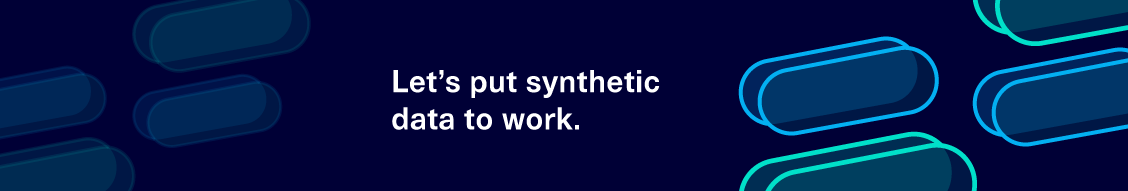